# Preprocessing x sensor placement -> latent space

What the AER actually sees is `client_datasets` -> `preprocess_clients` -> `(N, W, F)` windows.
Two things upstream of that are still unexamined: **where** the channels come from (placement,
never wired into the FL path) and **what** is done to them in time (aggregation, windowing,
scaling, and transforms we do not apply at all).

This notebook makes both axes explicit and scores them on the same two questions:

| block | what it answers |
|---|---|
| SS.2-4 | what am I feeding the model? (widget: raw -> transformed -> aggregated -> scaled window) |
| SS.5 | what is not applied yet, and does it change the input statistics at all (no training) |
| SS.7-8 | grid `placement x preprocessing` on ONE world, trained once each, cached to disk |
| SS.11 | the same grid across worlds; the ranking only counts if it replicates |
| SS.12 | pick any grid cell and look at its latent space directly |

Rules kept from the two source notebooks: `preprocess_clients` and `FPLTrainer` are imported and
never re-implemented; placement enters as a **column selection**, no re-simulation; ground truth
(`drift_district`, `gt_drift_schedule`) enters at scoring time only. Persistence mirrors
`aer_federated_sandbox_plot`'s `fed_sandbox/<world_id>/<run_id>/` + `runs.csv` pattern, adapted to
a grid: `run_cell` (SS.7) is the single entry point every section calls, so nothing trains twice
for the same `(world, strategy, transform, scaling, prep)`.

## 0. Setup

In [1]:
from __future__ import annotations
import copy, itertools, json, pathlib, sys, time, warnings

import numpy as np, pandas as pd, torch, yaml
warnings.filterwarnings("ignore")

HERE = pathlib.Path.cwd().resolve()
ROOT = next((p for p in [HERE, *HERE.parents]
             if (p / "conf" / "base" / "parameters.yml").exists()
             and (p / "src" / "fedwater").is_dir()), None)
assert ROOT is not None, "run this from inside the fedwater repo (notebooks/...)"
for p in (ROOT / "src", ROOT / "notebooks", ROOT, HERE):
    if p.exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from notebooks.SensorPlacement import placement_poc as P     
from fedwater.pipelines.fl_preprocessing.nodes import preprocess_clients
from fedwater.pipelines.fl_training.federated import FPLTrainer
from fedwater.pipelines.fl_training.nodes import effective_fl_seed
from fedwater.pipelines.drift_detection.nodes import compute_drift_signals
from fedwater.pipelines.dependence_oracle.nodes import deseasonalize

BASE_PARAMS = yaml.safe_load((ROOT / "conf" / "base" / "parameters.yml").read_text())
SEED   = BASE_PARAMS.get("seed", 42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SANDBOX = HERE / "latent_sandbox"; SANDBOX.mkdir(exist_ok=True)
pd.set_option("display.width", 170)

print(f"root {ROOT}\ndevice {DEVICE}  seed {SEED}  sandbox {SANDBOX}")

root C:\Users\arthu\USPy\10_Mestrado\fedWater
device cuda  seed 42  sandbox C:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\prospection\latent_sandbox


## 1. World and configuration

`discover_worlds` reads the experiments cache directly. Only `baseline` worlds are used: under
`partial`/`isolated` a topology-driven placement sees the same pipes the labels come from.

In [2]:
index = P.discover_worlds(ROOT)
assert len(index) and index["usable"].any(), "no usable cached worlds"
usable = index[index["usable"] & (index["variant"] == "baseline")]
display(usable[["tag", "sim_seed", "consumption_map", "n_months", "drift_district"]]
        .reset_index(drop=True))

WORLD = usable.iloc[70]                       # <- the single-world study
ART   = P.load_world(WORLD["dir"])
TIME  = ART["params"]["time"]
STEPS_DAY   = ART["steps_day"]
FL_BASE     = copy.deepcopy(ART["params"].get("fl", BASE_PARAMS["fl"]))
FL_BASE["training"]["device"] = DEVICE
TRUTH_CLIENT = WORLD.get("drift_district")


def drift_start(world_dir, n_months) -> int:
    """First drifted month, from gt_drift_schedule; midpoint if absent."""
    f = pathlib.Path(world_dir) / "clone" / "data" / "03_primary" / "gt_drift_schedule.csv"
    if f.exists():
        d = pd.read_csv(f)
        col = next((c for c in d.columns if "month" in c.lower()), None)
        if col is not None and len(d):
            v = pd.to_numeric(d[col], errors="coerce").dropna()
            if len(v):
                return int(v.min())
    return int(n_months) // 2


DRIFT_START = drift_start(WORLD["dir"], TIME["n_months"])
CURRENT_WORLD = WORLD["sim_hash"]            # tracks which world CLIENTS/ART currently hold
print(f"{WORLD['tag']}  |  drift {TRUTH_CLIENT} from month {DRIFT_START}  |  "
      f"{TIME['n_months']} months @ {TIME['resolution_h']}h  |  steps/day {STEPS_DAY}")

,tag,sim_seed,consumption_map,n_months,drift_district
0,Cli__LR_LR_LR_LR_LI__baseline,42,LR_LR_LR_LR_LI,48,District_C
1,Dlr__LR_LR_LR_LI_LI__baseline,43,LR_LR_LR_LI_LI,48,District_D
2,Cli__LR_LR_LR_LI_LI__baseline,43,LR_LR_LR_LI_LI,48,District_C
3,Dlr__LR_LR_LR_LI_LI__baseline,42,LR_LR_LR_LI_LI,48,District_D
4,Clc__LR_LI_LI_LC_LR__baseline,42,LR_LI_LI_LC_LR,30,District_C
...,...,...,...,...,...
80,Bli__LR_LR_LR_LI_LI__baseline,43,LR_LR_LR_LI_LI,48,District_B
81,Elr__LR_LR_LR_LR_HR__baseline,44,LR_LR_LR_LR_HR,48,District_E
82,Elr__LR_LR_LR_LR_LI__baseline,43,LR_LR_LR_LR_LI,48,District_E
83,Elr__LR_LR_LR_LR_LI__baseline,42,LR_LR_LR_LR_LI,48,District_E


Dli__LI_LR_LR_LR_LI__baseline  |  drift District_D from month 6  |  30 months @ 1h  |  steps/day 24


## 2. Placement -> client datasets

`strategies()` returns a placement per rule; `build_series()` turns it into the sensor long frame.
The only new code is the repackaging into the wide `District_*.csv` schema
(`timestamp, month, p_*, q_*`) that `preprocess_clients` consumes -- this is the join that was
missing between the placement POC and the FL stack.

In [4]:
STRATEGIES = ["manual", "variance", "boundary"]      # per the placement POC finding

cands       = P.candidate_table(ART["wn"], ART["districts"])
feats, dist = P.topology_features(ART["wn"], ART["districts"], cands)
stats       = P.residual_stats(ART["pressures"], ART["flows"], cands, STEPS_DAY)
PLACEMENTS  = {k: v for k, v in
               P.strategies(cands, feats, stats, dist, ART["params"], seed=SEED).items()
               if k in STRATEGIES}


def clients_from_placement(art, placement, noise=False, seed=SEED,
                           kinds=None) -> dict[str, pd.DataFrame]:
    """placement -> {district: wide frame} in the client_datasets schema.

    kinds: subset of {"pressure","flow"} to keep (filters AFTER selection -- the candidates
    still competed under the full 2p+3q template). None keeps everything.
    """
    ss = P.build_series(art["pressures"], art["flows"], placement,
                        art["params"]["noise"] if noise else None, seed)
    if kinds:
        ss = ss[ss["kind"].isin(kinds)]
    wide  = ss.pivot(index="step", columns="sensor", values="observed").sort_index()
    month = ss.drop_duplicates("step").set_index("step")["month"].sort_index()
    key   = ss.drop_duplicates("sensor").set_index("sensor")["district"]
    res_h = art["params"]["time"]["resolution_h"]
    ts    = pd.date_range("2020-01-01", periods=len(wide), freq=f"{int(res_h)}h")

    out = {}
    for d, grp in key.groupby(key):
        cols = sorted(grp.index)                       # p_* then q_*, stable across clients
        f = wide[cols].copy().reset_index(drop=True)
        f.insert(0, "month", month.to_numpy())
        f.insert(0, "timestamp", ts)
        out[d] = f
    return out


def assert_equal_channels(clients: dict[str, pd.DataFrame]):
    """FedAvg needs identical architectures -- every client must carry the same channel count."""
    n = {c: len([x for x in f.columns if x not in ("timestamp", "month")])
         for c, f in clients.items()}
    if len(set(n.values())) > 1:
        raise AssertionError(f"channel count differs across clients (breaks FedAvg): {n}")


CLIENTS = {s: clients_from_placement(ART, pl, kinds=("flow",)) for s, pl in PLACEMENTS.items()}
# CLIENTS = {s: clients_from_placement(ART, pl, kinds=("flow",))          # flow-only, 3 channels
#            for s, pl in PLACEMENTS.items()}
for s, frames in CLIENTS.items():
    assert_equal_channels(frames)

CHANNELS = {s: {c: [x for x in f.columns if x not in ("timestamp", "month")]
                for c, f in d.items()} for s, d in CLIENTS.items()}
pd.DataFrame({s: {c: ",".join(v) for c, v in ch.items()} for s, ch in CHANNELS.items()})

,manual,variance,boundary
District_A,"q_100,q_102,q_85","q_102,q_103,q_136","q_103,q_104,q_176"
District_B,"q_135,q_157,q_165","q_129,q_131,q_134","q_133,q_134,q_136"
District_C,"q_110,q_119,q_91","q_104,q_119,q_97","q_129,q_95,q_97"
District_D,"q_38,q_69,q_96","q_45,q_94,q_96","q_44,q_69,q_96"
District_E,"q_11,q_19,q_59","q_145,q_53,q_67","q_181,q_65,q_67"


## 3. The preprocessing stack

Two insertion points, deliberately kept apart:

* **before windowing** -- a transform on the client frame (`none | slog | diff | deseason_own |
  deseason_shared`). `preprocess_clients` then runs verbatim on the transformed frame.
* **after windowing** -- the scaling axis. `preprocess_clients` always fits a per-client MinMax
  on the commissioning months; `rescale_windows` inverts that affine map with `fl_scalers` and
  re-applies whatever we asked for, so `none` (physical units) and `zscore` are reachable
  without forking pipeline code.

In [5]:
def _cell_index(n, steps_day, month):
    day = np.arange(n) // steps_day
    return pd.DataFrame({"month": np.asarray(month), "hour": np.arange(n) % steps_day,
                         "weekend": (day % 7) >= 5})


def _slog(x):                       # flows are signed -- log1p on the magnitude
    return np.sign(x) * np.log1p(np.abs(x))


def deseason_shared(frames: dict, steps_day: int, k: int = 4) -> dict:
    """Remove the top-k PCs of the POOLED (month,hour,weekend) profile matrix.

    Each component is mean-zero across cells by construction, so a channel's own LEVEL
    survives -- the difference from `deseason_own`, which subtracts each channel's own cell
    means and therefore deletes exactly the level ladder the regime codes assert.
    """
    cols = {c: [x for x in f.columns if x not in ("timestamp", "month")] for c, f in frames.items()}
    any_f = next(iter(frames.values()))
    cells = _cell_index(len(any_f), steps_day, any_f["month"].to_numpy())
    gid = cells.groupby(["month", "hour", "weekend"], sort=True).ngroup().to_numpy()
    ncell = gid.max() + 1

    stack, names = [], []
    for c, f in frames.items():
        for x in cols[c]:
            v = f[x].to_numpy(float)
            stack.append(np.bincount(gid, v, ncell) / np.bincount(gid, minlength=ncell))
            names.append((c, x))
    Pm = np.column_stack(stack)                              # cells x channels
    mu, sd = Pm.mean(0), Pm.std(0, ddof=0)
    Z = (Pm - mu) / np.where(sd > 0, sd, 1.0)
    U, _, _ = np.linalg.svd(Z, full_matrices=False)
    B = U[:, :k]
    fitted = (B @ (B.T @ Z)) * np.where(sd > 0, sd, 1.0)     # channel units, mean-zero over cells

    out = {c: f.copy() for c, f in frames.items()}
    for j, (c, x) in enumerate(names):
        out[c][x] = out[c][x].to_numpy(float) - fitted[gid, j]
    return out


def apply_transform(frames: dict, name: str, steps_day: int) -> dict:
    if name == "none":
        return frames
    if name == "deseason_shared":
        return deseason_shared(frames, steps_day)
    out = {}
    for c, f in frames.items():
        g = f.copy()
        cols = [x for x in g.columns if x not in ("timestamp", "month")]
        if name == "slog":
            g[cols] = _slog(g[cols].to_numpy(float))
        elif name == "diff":
            g[cols] = g[cols].diff().fillna(0.0)
        elif name == "deseason_own":            # fedwater invariant 5, month-aware
            wide = g[cols].copy()
            wide.index = np.arange(len(g))
            res = deseasonalize(wide, steps_day, g["month"].copy(), month_aware=True)
            g[cols] = np.asarray(res)
        else:
            raise KeyError(name)
        out[c] = g
    return out


TRANSFORMS = ["none", "slog", "diff", "deseason_own", "deseason_shared"]

In [6]:
def _scaler_bounds(scalers: pd.DataFrame, client: str, sensors) -> tuple[np.ndarray, np.ndarray]:
    """(min, max) per channel from fl_scalers, whatever it calls its columns."""
    low = {c.lower(): c for c in scalers.columns}
    ccol = next(low[k] for k in ("district", "client", "partition", "name") if k in low)
    scol = next(low[k] for k in ("sensor", "feature", "channel", "column") if k in low)
    mncol = next(c for c in scalers.columns if "min" in c.lower())
    mxcol = next(c for c in scalers.columns if "max" in c.lower())
    g = scalers[scalers[ccol] == client].drop_duplicates(scol).set_index(scol)
    return (g.loc[list(sensors), mncol].to_numpy(float),
            g.loc[list(sensors), mxcol].to_numpy(float))


def rescale_windows(fl_windows: dict, scalers: pd.DataFrame, mode: str, fl: dict) -> dict:
    """minmax_ref (as-is) | none (physical units) | zscore (per client-channel)."""
    if mode == "minmax_ref":
        return fl_windows
    lo, hi = fl["preprocessing"]["feature_range"]
    out = {}
    for c, d in fl_windows.items():
        mn, mx = _scaler_bounds(scalers, c, d["sensors"])
        raw = (d["windows"].astype(np.float64) - lo) / (hi - lo) * (mx - mn) + mn
        if mode == "none":
            w = raw
        elif mode == "zscore":
            ref = d["labels"] < fl["preprocessing"]["reference_months"]
            src = raw[ref] if ref.any() else raw
            mu = src.reshape(-1, src.shape[-1]).mean(0)
            sd = src.reshape(-1, src.shape[-1]).std(0)
            w = (raw - mu) / np.where(sd > 0, sd, 1.0)
        else:
            raise KeyError(mode)
        out[c] = {**d, "windows": w.astype(np.float32)}
    return out


SCALINGS = ["minmax_ref", "none", "zscore"]

_WIN_CACHE: dict = {}


def build_windows(strategy: str, transform: str, prep: dict, clients=None, cap=None):
    """(fl_windows, scalers, fl_cfg) for one (placement, transform, prep params) cell."""
    key = (CURRENT_WORLD, strategy, transform, tuple(sorted(prep.items())),
          tuple(clients or ()), cap)
    if key in _WIN_CACHE:
        return _WIN_CACHE[key]
    fl = copy.deepcopy(FL_BASE)
    fl["preprocessing"].update(prep)
    frames = CLIENTS[strategy]
    if clients:
        frames = {c: frames[c] for c in clients}
    frames = apply_transform(frames, transform, STEPS_DAY)
    fw, sc, _ = preprocess_clients(frames, fl, TIME)
    if cap:
        for c, d in fw.items():
            n = len(d["windows"])
            if n > cap:
                i = np.linspace(0, n - 1, cap).round().astype(int)
                d["windows"], d["labels"] = d["windows"][i], d["labels"][i]
                d["window_start_step"] = d["window_start_step"][i]
    _WIN_CACHE[key] = (fw, sc, fl)
    return _WIN_CACHE[key]


PREP_BASE = dict(interval_agg_h=FL_BASE["preprocessing"]["interval_agg_h"],
                 window_size=FL_BASE["preprocessing"]["window_size"],
                 step_size=FL_BASE["preprocessing"]["step_size"])

fw, sc, _fl = build_windows("manual", "none", PREP_BASE)
print("base cell:", {c: d["windows"].shape for c, d in fw.items()})
inv = rescale_windows(fw, sc, "none", _fl)
c0 = next(iter(fw))
print(f"inversion check ({c0}) -- physical range "
      f"{inv[c0]['windows'].min():.3f}..{inv[c0]['windows'].max():.3f}  "
      f"vs scaled {fw[c0]['windows'].min():.2f}..{fw[c0]['windows'].max():.2f}")

base cell: {'District_A': (9528, 84, 3), 'District_B': (9528, 84, 3), 'District_C': (9528, 84, 3), 'District_D': (9528, 84, 3), 'District_E': (9528, 84, 3)}
inversion check (District_A) -- physical range 0.527..13.689  vs scaled -1.07..1.15


## 4. What am I feeding the model?

Pick 2-3 clients, a channel, the preprocessing parameters, and scrub the window index. Rows:

1. **client series** after the transform, with the selected window shaded -- the full context.
2. **the window the model sees**, one line per client, in whatever units the scaling leaves.

Windows are rebuilt on change for the selected clients only, and cached.

In [ ]:
import ipywidgets as W
import matplotlib.pyplot as plt
from IPython.display import display



print(f"{WORLD['tag']}  |  drift {TRUTH_CLIENT} from month {DRIFT_START}  |  "
      f"{TIME['n_months']} months @ {TIME['resolution_h']}h  |  steps/day {STEPS_DAY}")


ALL_CLIENTS = sorted(CLIENTS["manual"])
_c = W.SelectMultiple(options=ALL_CLIENTS, value=tuple(ALL_CLIENTS[:3]), rows=5,
                      description="clients")
_s = W.Dropdown(options=STRATEGIES, value="manual", description="placement")
_t = W.Dropdown(options=TRANSFORMS, value="none", description="transform")
_k = W.Dropdown(options=SCALINGS, value="minmax_ref", description="scaling")
_a = W.Dropdown(options=[1, 2, 3, 4, 6, 8], value=PREP_BASE["interval_agg_h"], description="agg h")
_w = W.Dropdown(options=[12, 24, 48, 84, 168], value=PREP_BASE["window_size"], description="window")
_p = W.Dropdown(options=[1, 3, 6, 12, 24], value=PREP_BASE["step_size"], description="stride")
_ch = W.Dropdown(options=["ch 0", "ch 1", "ch 2", "ch 3", "ch 4"], value="ch 0", description="channel")
_i = W.IntSlider(value=0, min=0, max=100, step=1, description="window", continuous_update=False,
                 layout=W.Layout(width="95%"))
_o = W.Output()


def _draw(*_):
    clients = list(_c.value)[:3]
    if not clients:
        return
    prep = dict(interval_agg_h=_a.value, window_size=_w.value, step_size=_p.value)
    try:
        fw, sc, fl = build_windows(_s.value, _t.value, prep, clients=tuple(clients))
        fw = rescale_windows(fw, sc, _k.value, fl)
    except Exception as err:
        with _o:
            _o.clear_output(wait=True); print(f"{type(err).__name__}: {err}")
        return

    j = int(_ch.value.split()[1])
    n = min(len(fw[c]["windows"]) for c in clients)
    _i.max = n - 1
    idx = min(_i.value, n - 1)
    src = apply_transform({c: CLIENTS[_s.value][c] for c in clients}, _t.value, STEPS_DAY)

    with _o:
        _o.clear_output(wait=True)
        fig, ax = plt.subplots(2, 1, figsize=(12, 6),
                               gridspec_kw={"height_ratios": [2, 1]})
        for c in clients:
            d, f = fw[c], src[c]
            cols = [x for x in f.columns if x not in ("timestamp", "month")]
            jj = min(j, len(cols) - 1)
            ax[0].plot(f[cols[jj]].to_numpy(), lw=.4, alpha=.75,
                       label=f"{c} · {cols[jj]}")
            start = int(d["window_start_step"][idx])
            span = _w.value * _a.value // int(TIME["resolution_h"])
            ax[0].axvspan(start, start + span, color="k", alpha=.10)
            ax[1].plot(d["windows"][idx, :, jj], lw=1.2, marker=".", ms=3, label=c)
        ax[0].legend(fontsize=7, ncol=3); ax[0].set_title(
            f"{_s.value} · {_t.value} · agg {_a.value}h · window {_w.value} · stride {_p.value}"
            f"  |  {n} windows/client")
        ax[1].set_title(f"window {idx} as the model sees it ({_k.value})"); ax[1].legend(fontsize=7)
        for a in ax:
            a.grid(alpha=.25)
        fig.tight_layout(); plt.show()

        rows = [{"client": c, "windows": len(fw[c]["windows"]),
                 "shape": str(fw[c]["windows"].shape[1:]),
                 "min": float(fw[c]["windows"].min()), "max": float(fw[c]["windows"].max()),
                 "std": float(fw[c]["windows"].std())} for c in clients]
        display(pd.DataFrame(rows).round(3))


for ctl in (_c, _s, _t, _k, _a, _w, _p, _ch, _i):
    ctl.observe(_draw, names="value")
display(W.VBox([W.HBox([_c, W.VBox([_s, _t, _k]), W.VBox([_a, _w, _p, _ch])]), _i, _o]))
_draw()


## 5. What we are not applying yet

`fl_preprocessing` currently does: hourly -> `interval_agg_h` aggregation -> sliding window ->
per-client MinMax fitted on the commissioning months. Nothing else. Four candidates, and the
reason each is not obviously right:

| axis | what it does | why it might help | what it costs |
|---|---|---|---|
| `slog` | signed `log1p` | compresses the peaky low-density profiles; the demand ladder is multiplicative | flattens exactly the amplitude that distinguishes regimes |
| `diff` | first difference | kills the level and the slow seasonal ramp, leaves innovations | drift is a **level** change; this is the wrong tool for drift detection and possibly the right one for dependence |
| `deseason_own` | per-channel `(month,hour,weekend)` mean removed | `fedwater` invariant 5; without it, isolated districts look coupled | deletes the client's monthly level -- i.e. the drift signal itself |
| `deseason_shared` | top-4 PCs of the **pooled** cell-profile matrix removed | removes the common exogenous season while every channel keeps its own level | assumes the confound is low-rank and shared |
| `scaling=none/zscore` | invert the per-client MinMax | MinMax fitted on commissioning months makes every client identical at t0; a level change survives only as an excursion | different clients end up on different scales, which FedAvg has to absorb |

The cell below scores these **without training**: mean absolute cross-client correlation of the
client-mean signal (want low -- less shared exogenous drive) against between-district variance
share of the channel level (want high -- the ladder survives). A transform that improves only one
of the two is a trade, not an improvement.

In [8]:
def prep_diagnostics(strategy="manual", transforms=TRANSFORMS) -> pd.DataFrame:
    rows = []
    for t in transforms:
        fr = apply_transform(CLIENTS[strategy], t, STEPS_DAY)
        sig, lev = {}, {}
        for c, f in fr.items():
            cols = [x for x in f.columns if x not in ("timestamp", "month")]
            V = f[cols].to_numpy(float)
            Vz = (V - V.mean(0)) / np.where(V.std(0) > 0, V.std(0), 1.0)
            sig[c] = Vz.mean(1)
            lev[c] = V.mean(0)                       # per-channel level
        ks = sorted(sig)
        R = np.abs(np.corrcoef(np.column_stack([sig[k] for k in ks]).T))
        off = R[np.triu_indices(len(ks), 1)]
        L = np.concatenate([lev[k] for k in ks])
        g = np.concatenate([[i] * len(lev[k]) for i, k in enumerate(ks)])
        Lz = (L - L.mean()) / (L.std() or 1.0)
        between = sum(len(Lz[g == u]) * (Lz[g == u].mean() - Lz.mean()) ** 2 for u in np.unique(g))
        rows.append(dict(transform=t, cross_client_r=float(np.nanmean(off)),
                         level_eta2=float(between / (np.sum((Lz - Lz.mean()) ** 2) or 1.0))))
    return pd.DataFrame(rows)


display(prep_diagnostics().round(3))
print("want: cross_client_r LOW (less shared exogenous drive), level_eta2 HIGH (ladder survives)")

,transform,cross_client_r,level_eta2
0,none,0.599,0.444
1,slog,0.611,0.462
2,diff,0.493,0.482
3,deseason_own,0.144,0.098
4,deseason_shared,0.102,0.443


want: cross_client_r LOW (less shared exogenous drive), level_eta2 HIGH (ladder survives)


## 6. Scoring a cell

Two families of score, never mixed:

* **latent** -- `sil_district` / `sil_month` (cosine silhouette), `month_within_district`
  (month decoded *inside* each client, so it cannot ride the client fingerprint), `eff_dim`.
* **drift** -- `compute_drift_signals` on the prototypes, verbatim: `drift_rank` of the true
  drifted district (1 is correct), `drift_sep` in robust units of the other clients' spread
  (median/MAD, so one collapsed-variance client can't blow the ratio up), `drift_gap` (target
  mean delta / next-largest, scale-free) and `others_sd` so a near-zero denominator is visible
  rather than silently inflating `drift_sep`.

In [9]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def _probe(Z, y, seed=0):
    u, cnt = np.unique(y, return_counts=True)
    if len(u) < 2:
        return np.nan
    Ztr, Zte, ytr, yte = train_test_split(Z, y, test_size=.3, random_state=seed,
                                          stratify=y if cnt.min() >= 2 else None)
    return float(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1500))
                 .fit(Ztr, ytr).score(Zte, yte))


def latent_metrics(lt, seed=0, sil_n=2000, probe_n=6000) -> dict:
    f = [c for c in lt.columns if c.startswith("f") and c[1:].isdigit()]
    Z, d, m = lt[f].to_numpy(float), lt["district"].to_numpy(), lt["month"].to_numpy()
    rng = np.random.default_rng(seed)
    i = rng.choice(len(Z), min(sil_n, len(Z)), replace=False)
    p = rng.choice(len(Z), min(probe_n, len(Z)), replace=False)
    ev = PCA().fit(Z).explained_variance_ratio_
    within = [a for a in (_probe(Z[d == c], m[d == c], seed) for c in np.unique(d))
              if not np.isnan(a)]
    return dict(sil_district=float(silhouette_score(Z[i], d[i], metric="cosine")),
                sil_month=float(silhouette_score(Z[i], m[i], metric="cosine")),
                month_within_district=float(np.mean(within)) if within else np.nan,
                probe_district=_probe(Z[p], d[p], seed),
                eff_dim=float(1.0 / (ev ** 2).sum()))


def _auroc(y, s):
    from scipy import stats as sps
    y, s = np.asarray(y, bool), np.asarray(s, float)
    if y.all() or not y.any():
        return np.nan
    r = sps.rankdata(s); n1, n0 = y.sum(), (~y).sum()
    return float((r[y].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def drift_metrics(ph: pd.DataFrame, fl: dict, truth=None, start=None) -> dict:
    truth, start = truth or TRUTH_CLIENT, DRIFT_START if start is None else start
    ds = compute_drift_signals(ph, fl)
    if truth not in set(ds["client"]):
        return dict(drift_rank=np.nan, drift_sep=np.nan, drift_gap=np.nan,
                   others_sd=np.nan, drift_auroc=np.nan)
    post = ds[ds["month"] >= start]
    m = post.groupby("client")["delta_first"].mean().abs()
    others = m.drop(truth)
    mad = float(np.median(np.abs(others - others.median()))) or float(others.mean()) or 1.0
    tgt = ds[ds["client"] == truth]
    return dict(
        drift_rank=float(m.rank(ascending=False)[truth]),
        drift_sep=float((m[truth] - others.median()) / mad),
        drift_gap=float(m[truth] / (others.max() or np.nan)),
        others_sd=float(others.std(ddof=0)),
        drift_auroc=_auroc(tgt["month"].to_numpy() >= start, tgt["delta_first"].abs().to_numpy()))

## 7. Persistence -- `latent_sandbox/`

Same idea as `aer_federated_sandbox_plot`'s `fed_sandbox/<world_id>/<run_id>/` + `runs.csv`,
adapted to a grid instead of a single run: `cell_id` is deterministic from the cell spec (no
timestamp), so re-running the same grid is a cache hit, not a new directory.

```
latent_sandbox/
  runs.csv                              # one row per (world_id, cell_id) -- the registry
  clustering_by_phase.csv               # SS.14, every (cell, round, phase)
  migration.csv                         # SS.15, init -> final cluster crossings
  <world_id>/<cell_id>/
    config.json  metrics.json
    latent_trajectories.parquet         # final model, all windows
    prototype_history.parquet           # per ROUND per client per month -- the round axis
    drift_signals.parquet
    latents_by_round.parquet            # fixed-subset latent snapshots per round (SS.7a)
    metrics_by_round.parquet            # optional: latent_metrics per round
    similarity_by_phase.parquet         # SS.14 per-pair similarities
    clusters_by_phase.parquet           # SS.14 per-client labels, per (round, phase)
```

`run_cell` is the single entry point -- SS.8's sweep, SS.11's multi-world loop, and SS.12's
explorer all go through it, so a cell trains once no matter how many places ask for it.

In [10]:
def cell_id_for(strategy, transform, scaling, prep) -> str:
    return (f"{strategy}__{transform}__{scaling}"
            f"__a{prep['interval_agg_h']}w{prep['window_size']}s{prep['step_size']}")


def _write_table(df: pd.DataFrame, path_base: pathlib.Path) -> None:
    try:
        df.to_parquet(path_base.with_suffix(".parquet"), index=False)
    except Exception:
        df.to_csv(path_base.with_suffix(".csv.gz"), index=False)


def _read_table(path_base: pathlib.Path):
    for suf in (".parquet", ".csv.gz"):
        p = path_base.with_suffix(suf)
        if p.exists():
            return pd.read_parquet(p) if suf == ".parquet" else pd.read_csv(p)
    return None


CELL_TABLES = ("latent_trajectories", "prototype_history", "drift_signals",
               "latents_by_round", "metrics_by_round",
               "similarity_by_phase", "clusters_by_phase")


def save_cell(world_id: str, cell_id: str, spec: dict, lt: pd.DataFrame, ph: pd.DataFrame,
             drift: pd.DataFrame, metrics: dict, **tables) -> pathlib.Path:
    """The three core tables plus any extras. `snaps=` is stored as latents_by_round."""
    out = SANDBOX / world_id / cell_id
    out.mkdir(parents=True, exist_ok=True)
    (out / "config.json").write_text(json.dumps(spec, indent=2))
    (out / "metrics.json").write_text(json.dumps(metrics, indent=2))
    _write_table(lt, out / "latent_trajectories")
    _write_table(ph, out / "prototype_history")
    _write_table(drift, out / "drift_signals")
    for name, df in tables.items():
        if df is None:
            continue
        key = "latents_by_round" if name == "snaps" else name
        _write_table(df.reset_index() if df.index.name else df, out / key)

    reg_path = SANDBOX / "runs.csv"
    reg = pd.read_csv(reg_path) if reg_path.exists() else pd.DataFrame()
    if len(reg):
        reg = reg[~((reg.world_id == world_id) & (reg.cell_id == cell_id))]
    row = {"world_id": world_id, "cell_id": cell_id,
          "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"), **metrics}
    pd.concat([reg, pd.DataFrame([row])], ignore_index=True).to_csv(reg_path, index=False)
    return out


def load_cell(world_id: str, cell_id: str) -> dict | None:
    d = SANDBOX / world_id / cell_id
    if not (d / "metrics.json").exists():
        return None
    out = dict(spec=json.loads((d / "config.json").read_text()),
              metrics=json.loads((d / "metrics.json").read_text()))
    for name in CELL_TABLES:
        out[name] = _read_table(d / name)
    return out


def save_analysis(world_id: str, cell_id: str, **tables) -> pathlib.Path:
    """Write extra analysis tables into an already-saved cell directory (SS.14/15)."""
    out = SANDBOX / world_id / cell_id
    if not out.exists():
        raise FileNotFoundError(f"{out} does not exist -- run SS.8 first")
    for name, df in tables.items():
        if df is not None:
            _write_table(df.reset_index() if df.index.name else df, out / name)
    return out


def load_registry() -> pd.DataFrame:
    p = SANDBOX / "runs.csv"
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

### 7a. The round axis

Two different per-round objects, and they are not interchangeable:

* **`prototype_history`** already carries `round` -- `FPLTrainer` emits it. Every per-round
  *prototype* analysis (SS.14 similarity, SS.15 migration) reads this and needs **no retraining**,
  so cells trained before this section still work.
* **`latents_by_round`** is new and needs `SnapshotFPLTrainer`: the same fixed subset of windows
  encoded after every round, so the latent *cloud* can be followed frame to frame. `round = -1`
  is the shared untrained init -- the only true control in the notebook.

Snapshots are taken post-local-update, **pre-FedAvg** (the personalized view), exactly as in
`aer_federated_sandbox_plot`. `FPLTrainer`'s protocol, seeding and FedAvg are untouched.

In [11]:
class SnapshotFPLTrainer(FPLTrainer):
    """FPLTrainer + fixed-subset latent snapshots per round. Protocol untouched."""

    def __init__(self, client_windows, fl, seed, every=1, points=900):
        super().__init__(client_windows, fl, seed)
        self.starts = {c: client_windows[c]["window_start_step"] for c in self.clients}
        self.snap_every = int(every or 0)
        self.n_rounds, self.snap_rows = 0, []

        rng = np.random.default_rng(seed)
        per = max(1, int(points) // len(self.clients))
        self.snap_idx = {
            c: np.sort(rng.choice(len(self.data[c][0]),
                                  min(per, len(self.data[c][0])), replace=False))
            for c in self.clients
        }
        if self.snap_every:
            for c in self.clients:
                self._snapshot(c, -1)                      # shared untrained init

    @torch.no_grad()
    def _snapshot(self, client, round_idx):
        model, bs = self.models[client], self.cfg_t["batch_size"]
        mode = model.training
        model.eval()
        w = self.data[client][0][self.snap_idx[client]]
        z = torch.cat([model.encode(w[i:i + bs, 1:-1])
                       for i in range(0, len(w), bs)]).cpu().numpy()
        model.train(mode)

        idx = self.snap_idx[client]
        df = pd.DataFrame(z, columns=[f"f{i}" for i in range(z.shape[1])])
        df.insert(0, "month", self.data[client][1].cpu().numpy()[idx])
        df.insert(0, "window", self.starts[client][idx])
        df.insert(0, "round", round_idx)
        df.insert(0, "district", client)
        self.snap_rows.append(df)

    # ------------------------------------------------------------- hooks
    def _local_update(self, client, round_idx):
        protos = super()._local_update(client, round_idx)
        if self.snap_every and (round_idx % self.snap_every == 0
                                or round_idx == self.n_rounds - 1):
            self._snapshot(client, round_idx)
        return protos

    def train(self, rounds):
        self.n_rounds = rounds
        return super().train(rounds)

    def snapshots(self):
        return pd.concat(self.snap_rows, ignore_index=True) if self.snap_rows else None


SNAPSHOT_EVERY  = 1      # 0 disables snapshots entirely
SNAPSHOT_POINTS = None #900    # fixed points per cell, split across clients
ROUND_METRICS   = True  # True = latent_metrics per round (adds ~1-2 s per round per cell)

In [12]:
def set_world_context(world_row):
    """Point ART/CLIENTS/etc at a different world. Called by run_cell when needed --
    not usually called directly."""
    global ART, TIME, STEPS_DAY, FL_BASE, TRUTH_CLIENT, DRIFT_START
    global CLIENTS, PLACEMENTS, _WIN_CACHE, CURRENT_WORLD
    ART = P.load_world(world_row["dir"])
    TIME, STEPS_DAY = ART["params"]["time"], ART["steps_day"]
    FL_BASE = copy.deepcopy(ART["params"].get("fl", BASE_PARAMS["fl"]))
    FL_BASE["training"]["device"] = DEVICE
    TRUTH_CLIENT = world_row.get("drift_district")
    DRIFT_START = drift_start(world_row["dir"], TIME["n_months"])

    cands = P.candidate_table(ART["wn"], ART["districts"])
    feats, dist = P.topology_features(ART["wn"], ART["districts"], cands)
    stats = P.residual_stats(ART["pressures"], ART["flows"], cands, STEPS_DAY)
    PLACEMENTS = {k: v for k, v in P.strategies(cands, feats, stats, dist, ART["params"],
                                                seed=SEED).items() if k in STRATEGIES}
    CLIENTS = {s: clients_from_placement(ART, pl) for s, pl in PLACEMENTS.items()}
    for s, frames in CLIENTS.items():
        assert_equal_channels(frames)
    _WIN_CACHE = {}
    CURRENT_WORLD = world_row["sim_hash"]


def train_cell(strategy, transform, scaling, prep, rounds=None, cap=None,
              snapshot_every=None, snapshot_points=None) -> dict:
    """Pure compute: windows -> SnapshotFPLTrainer -> latents, prototypes, per-round
    snapshots. No scoring, no saving."""
    fw, sc, fl = build_windows(strategy, transform, prep, cap=cap)
    fw = rescale_windows(fw, sc, scaling, fl)
    if rounds:
        fl = copy.deepcopy(fl); fl["training"]["rounds"] = rounds
    every = SNAPSHOT_EVERY if snapshot_every is None else snapshot_every
    pts = SNAPSHOT_POINTS if snapshot_points is None else snapshot_points

    tr = SnapshotFPLTrainer(fw, fl, effective_fl_seed(fl, SEED), every=every, points=pts)
    t0 = time.time()
    tr.train(fl["training"]["rounds"])

    def _tag(df):
        df = df.copy()
        df["hour"] = (df["window"] * TIME["resolution_h"] % 24).astype(int)
        df["drift_status"] = np.where(
            (df["district"] == TRUTH_CLIENT) & (df["month"] >= DRIFT_START), "drifted", "other")
        return df

    lt = _tag(tr.latent_trajectories(fw))
    snaps = tr.snapshots()
    snaps = None if snaps is None else _tag(snaps)
    ph = pd.DataFrame(tr.local_proto_rows)
    return dict(lt=lt, ph=ph, snaps=snaps, drift=compute_drift_signals(ph, fl), fl=fl, fw=fw,
               seconds=round(time.time() - t0, 1))


def score_cell(out: dict, strategy, transform, scaling, prep) -> dict:
    return dict(strategy=strategy, transform=transform, scaling=scaling, **prep,
               n_windows=int(sum(len(d["windows"]) for d in out["fw"].values())),
               n_rounds=int(out["fl"]["training"]["rounds"]),
               **latent_metrics(out["lt"]), **drift_metrics(out["ph"], out["fl"]),
               seconds=out["seconds"])


def metrics_by_round(snaps: pd.DataFrame | None) -> pd.DataFrame | None:
    """latent_metrics per snapshot round. Round -1 is the untrained control."""
    if snaps is None:
        return None
    return pd.DataFrame([{"round": int(r), "n": len(g), **latent_metrics(g)}
                         for r, g in snaps.groupby("round")])


def run_cell(world_row, strategy, transform, scaling, prep, rounds=None, cap=None,
             overwrite=False, save=True, return_tables=False, verbose=False) -> dict:
    """The single entry point. Trains + scores + persists a cell, or loads it from disk
    if it already exists under `latent_sandbox/<world_id>/<cell_id>/`."""
    if world_row["sim_hash"] != CURRENT_WORLD:
        set_world_context(world_row)
    wid, cid = world_row["sim_hash"], cell_id_for(strategy, transform, scaling, prep)

    cached = None if overwrite else load_cell(wid, cid)
    if cached is not None:
        row = {**cached["metrics"], "world_id": wid, "cell_id": cid, "tag": world_row["tag"],
              "cache_hit": True}
        if return_tables:
            row["_tables"] = cached
        if verbose:
            print(f"  [cached] {cid}")
        return row

    out = train_cell(strategy, transform, scaling, prep, rounds=rounds, cap=cap)
    row = score_cell(out, strategy, transform, scaling, prep)
    mbr = metrics_by_round(out["snaps"]) if ROUND_METRICS else None
    if save:
        save_cell(wid, cid, dict(strategy=strategy, transform=transform, scaling=scaling,
                                 prep=prep, rounds=rounds, cap=cap,
                                 snapshot_every=SNAPSHOT_EVERY),
                 out["lt"], out["ph"], out["drift"], row,
                 snaps=out["snaps"], metrics_by_round=mbr)
    row = {**row, "world_id": wid, "cell_id": cid, "tag": world_row["tag"], "cache_hit": False}
    if return_tables:
        row["_tables"] = {"latent_trajectories": out["lt"], "prototype_history": out["ph"],
                          "drift_signals": out["drift"], "latents_by_round": out["snaps"],
                          "metrics_by_round": mbr}
    if verbose:
        print("  ".join(f"{k}={v}" for k, v in row.items()
                        if k not in prep and not k.startswith("_")))
    return row

## 8. The grid, one world

Two blocks, ~36 cells. Block A holds the window geometry fixed and sweeps
`placement x transform x scaling`; block B holds the transform fixed and sweeps the geometry.
Crossing both fully would be 90 trains for little extra information -- the interaction that
matters is placement x transform.

`CAP` subsamples windows per client. Set it to `None` for the honest run; keep it while you are
still deciding the grid. Re-running this cell after the first pass is a disk-cache read, not a
retrain -- pass `overwrite=True` to `run_cell` (or delete the cell's directory) to force one.

In [13]:
CAP    = 3000        # windows per client; None = all
ROUNDS = None        # None = the world's own fl.training.rounds

PREP_BASE = {'interval_agg_h': 3, 'window_size': 84, 'step_size': 12}

PREP_GEOM = [PREP_BASE,
             dict(interval_agg_h=3, window_size=84, step_size=24),
             dict(interval_agg_h=4, window_size=48, step_size=12)]

GRID = ([dict(strategy=s, transform=t, scaling=k, prep=PREP_BASE)
         for s, t, k in itertools.product(STRATEGIES, TRANSFORMS, ["minmax_ref", "none"])]
        + [dict(strategy=s, transform="none", scaling="minmax_ref", prep=g)
           for s, g in itertools.product(STRATEGIES, PREP_GEOM[1:])])

print(f"{len(GRID)} cells")
pd.DataFrame([{**{k: v for k, v in g.items() if k != 'prep'}, **g['prep']} for g in GRID]).head(8)

36 cells


,strategy,transform,scaling,interval_agg_h,window_size,step_size
0,manual,none,minmax_ref,3,84,12
1,manual,none,none,3,84,12
2,manual,slog,minmax_ref,3,84,12
3,manual,slog,none,3,84,12
4,manual,diff,minmax_ref,3,84,12
5,manual,diff,none,3,84,12
6,manual,deseason_own,minmax_ref,3,84,12
7,manual,deseason_own,none,3,84,12


In [38]:
rows, fails = [], []
for n, g in enumerate(GRID, 1):
    tag = f"{g['strategy'][:4]}/{g['transform']}/{g['scaling']}/a{g['prep']['interval_agg_h']}w{g['prep']['window_size']}"
    try:
        r = run_cell(WORLD, **g, rounds=ROUNDS, cap=CAP)
        rows.append(r)
        flag = "cached" if r["cache_hit"] else f"{r['seconds']}s"
        print(f"[{n}/{len(GRID)}] {tag:<44} rank {r['drift_rank']:.0f}  "
              f"sep {r['drift_sep']:+.2f}  mwd {r['month_within_district']:.3f}  {flag}")
    except Exception as exc:
        fails.append({"cell": tag, "error": f"{type(exc).__name__}: {exc}"})
        print(f"[{n}/{len(GRID)}] {tag:<44} FAILED {type(exc).__name__}: {exc}")

RESULTS = pd.DataFrame(rows)
if fails:
    display(pd.DataFrame(fails))
print(f"saved under {SANDBOX}/{WORLD['sim_hash']}/  |  registry: {SANDBOX}/runs.csv")
RESULTS.sort_values(["drift_rank", "drift_sep"], ascending=[True, False]).head(12).round(3)

[1/36] manu/none/minmax_ref/a3w84                   rank 2  sep +1.36  mwd 0.160  20.1s
[2/36] manu/none/none/a3w84                         rank 1  sep +41.15  mwd 0.203  31.3s
[3/36] manu/slog/minmax_ref/a3w84                   rank 1  sep +3.44  mwd 0.176  43.8s
[4/36] manu/slog/none/a3w84                         rank 4  sep -1.00  mwd 0.172  32.5s
[5/36] manu/diff/minmax_ref/a3w84                   rank 1  sep +2.39  mwd 0.089  43.9s
[6/36] manu/diff/none/a3w84                         rank 2  sep +23.58  mwd 0.068  41.0s
[7/36] manu/deseason_own/minmax_ref/a3w84           rank 3  sep -0.14  mwd 0.028  44.6s
[8/36] manu/deseason_own/none/a3w84                 rank 1  sep +2.95  mwd 0.028  42.5s
[9/36] manu/deseason_shared/minmax_ref/a3w84        rank 3  sep -0.12  mwd 0.222  42.0s
[10/36] manu/deseason_shared/none/a3w84              rank 5  sep -2.32  mwd 0.260  46.4s
[11/36] vari/none/minmax_ref/a3w84                   rank 1  sep +2.30  mwd 0.093  45.4s
[12/36] vari/none/none/a3w84

,strategy,transform,scaling,interval_agg_h,window_size,step_size,n_windows,sil_district,sil_month,month_within_district,...,drift_rank,drift_sep,drift_gap,others_sd,drift_auroc,seconds,world_id,cell_id,tag,cache_hit
1,manual,none,none,3,84,12,2390,0.968,-0.089,0.203,...,1.0,41.148,4.774,0.004,0.993,31.3,e0f8c48c1006,manual__none__none__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,False
19,variance,deseason_shared,none,3,84,12,2390,0.999,-0.074,0.189,...,1.0,14.468,1.253,0.000,0.837,46.5,e0f8c48c1006,variance__deseason_shared__none__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,False
18,variance,deseason_shared,minmax_ref,3,84,12,2390,-0.005,-0.203,0.133,...,1.0,10.128,2.082,0.004,0.847,44.4,e0f8c48c1006,variance__deseason_shared__minmax_ref__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,False
30,manual,none,minmax_ref,3,84,24,1195,0.220,-0.194,0.164,...,1.0,5.693,1.041,0.011,0.938,24.7,e0f8c48c1006,manual__none__minmax_ref__a3w84s24,Dli__LI_LR_LR_LR_LI__baseline,False
31,manual,none,minmax_ref,4,48,12,2090,0.208,-0.261,0.319,...,1.0,3.904,1.036,0.009,0.972,28.7,e0f8c48c1006,manual__none__minmax_ref__a4w48s12,Dli__LI_LR_LR_LR_LI__baseline,False
2,manual,slog,minmax_ref,3,84,12,2390,0.316,-0.283,0.176,...,1.0,3.440,1.615,0.013,0.868,43.8,e0f8c48c1006,manual__slog__minmax_ref__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,False
32,variance,none,minmax_ref,3,84,24,1195,0.133,-0.211,0.128,...,1.0,3.066,1.204,0.012,0.792,24.6,e0f8c48c1006,variance__none__minmax_ref__a3w84s24,Dli__LI_LR_LR_LR_LI__baseline,False
7,manual,deseason_own,none,3,84,12,2390,-0.297,-0.321,0.028,...,1.0,2.954,1.194,0.008,0.604,42.5,e0f8c48c1006,manual__deseason_own__none__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,False
4,manual,diff,minmax_ref,3,84,12,2390,-0.105,-0.123,0.089,...,1.0,2.389,1.184,0.002,1.000,43.9,e0f8c48c1006,manual__diff__minmax_ref__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,False
10,variance,none,minmax_ref,3,84,12,2390,0.059,-0.200,0.093,...,1.0,2.298,1.274,0.036,0.868,45.4,e0f8c48c1006,variance__none__minmax_ref__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,False


## 9. Resume from disk

If you are picking this notebook back up in a fresh kernel, `RESULTS` rebuilds from the registry
with no retraining -- SS.7-8 only need re-running to add cells that were never saved.

In [14]:
def list_cells(world_id: str | None = None) -> pd.DataFrame:
    reg = load_registry()
    return reg if not world_id or not len(reg) else reg[reg.world_id == world_id]

RESULTS = list_cells(WORLD["sim_hash"])
print(f"{len(RESULTS)} cells on disk for {WORLD['tag']}")
RESULTS.sort_values(["drift_rank", "drift_sep"], ascending=[True, False]).head(10)

36 cells on disk for Dli__LI_LR_LR_LR_LI__baseline


,world_id,cell_id,saved_at,strategy,transform,scaling,interval_agg_h,window_size,step_size,n_windows,...,sil_month,month_within_district,probe_district,eff_dim,drift_rank,drift_sep,drift_gap,others_sd,drift_auroc,seconds
1,e0f8c48c1006,manual__none__none__a3w84s12,2026-09-07 15:54:04,manual,none,none,3,84,12,2390,...,-0.089025,0.202778,1.000000,2.445560,1.0,41.148116,4.773547,0.004151,0.993056,31.3
19,e0f8c48c1006,variance__deseason_shared__none__a3w84s12,2026-09-07 16:07:35,variance,deseason_shared,none,3,84,12,2390,...,-0.074031,0.188889,1.000000,2.697741,1.0,14.467799,1.253159,0.000011,0.836806,46.5
18,e0f8c48c1006,variance__deseason_shared__minmax_ref__a3w84s12,2026-09-07 16:06:48,variance,deseason_shared,minmax_ref,3,84,12,2390,...,-0.202562,0.133333,0.868898,3.770886,1.0,10.128165,2.082185,0.003923,0.847222,44.4
30,e0f8c48c1006,manual__none__minmax_ref__a3w84s24,2026-09-07 16:15:41,manual,none,minmax_ref,3,84,24,1195,...,-0.194245,0.163889,1.000000,3.845788,1.0,5.693159,1.040529,0.010666,0.937500,24.7
31,e0f8c48c1006,manual__none__minmax_ref__a4w48s12,2026-09-07 16:16:11,manual,none,minmax_ref,4,48,12,2090,...,-0.261421,0.319048,1.000000,1.841964,1.0,3.903764,1.036080,0.008575,0.972222,28.7
2,e0f8c48c1006,manual__slog__minmax_ref__a3w84s12,2026-09-07 15:54:49,manual,slog,minmax_ref,3,84,12,2390,...,-0.282759,0.176389,0.994421,1.824054,1.0,3.440369,1.614738,0.012819,0.868056,43.8
32,e0f8c48c1006,variance__none__minmax_ref__a3w84s24,2026-09-07 16:16:36,variance,none,minmax_ref,3,84,24,1195,...,-0.210779,0.127778,1.000000,3.745927,1.0,3.065526,1.204036,0.011618,0.791667,24.6
7,e0f8c48c1006,manual__deseason_own__none__a3w84s12,2026-09-07 15:58:18,manual,deseason_own,none,3,84,12,2390,...,-0.320843,0.027778,0.789400,5.588991,1.0,2.953695,1.193717,0.007878,0.604167,42.5
4,e0f8c48c1006,manual__diff__minmax_ref__a3w84s12,2026-09-07 15:56:08,manual,diff,minmax_ref,3,84,12,2390,...,-0.122733,0.088889,1.000000,2.270646,1.0,2.388999,1.183779,0.001742,1.000000,43.9
10,e0f8c48c1006,variance__none__minmax_ref__a3w84s12,2026-09-07 16:00:35,variance,none,minmax_ref,3,84,12,2390,...,-0.200429,0.093056,0.997211,2.423714,1.0,2.298139,1.273626,0.035611,0.868056,45.4


## 10. Figures

-- drift_sep


strategy                    boundary  manual  variance
transform       scaling                               
deseason_own    minmax_ref    -1.745  -0.137     1.247
                none          -0.736   2.954     1.140
deseason_shared minmax_ref    -4.625  -0.116    10.128
                none          -2.167  -2.324    14.468
diff            minmax_ref     1.462   2.389     0.023
                none           0.954  23.584     2.282
none            minmax_ref     1.864   3.526     2.682
                none          -0.836  41.148     1.265
slog            minmax_ref     0.994   3.440    -0.656
                none          -0.175  -0.995    -1.012

-- month_within_district


strategy                    boundary  manual  variance
transform       scaling                               
deseason_own    minmax_ref     0.029   0.028     0.038
                none           0.031   0.028     0.033
deseason_shared minmax_ref     0.175   0.222     0.133
                none           0.204   0.260     0.189
diff            minmax_ref     0.072   0.089     0.075
                none           0.093   0.068     0.114
none            minmax_ref     0.090   0.162     0.110
                none           0.206   0.203     0.224
slog            minmax_ref     0.106   0.176     0.115
                none           0.097   0.172     0.107

-- sil_district


strategy                    boundary  manual  variance
transform       scaling                               
deseason_own    minmax_ref    -0.038   0.010    -0.054
                none          -0.235  -0.297    -0.184
deseason_shared minmax_ref     0.097   0.030    -0.005
                none           1.000   1.000     0.999
diff            minmax_ref    -0.158  -0.105    -0.041
                none           0.125   0.038     0.215
none            minmax_ref    -0.052   0.184     0.096
                none           0.893   0.968     0.872
slog            minmax_ref    -0.117   0.316     0.086
                none           0.801   0.972     0.728

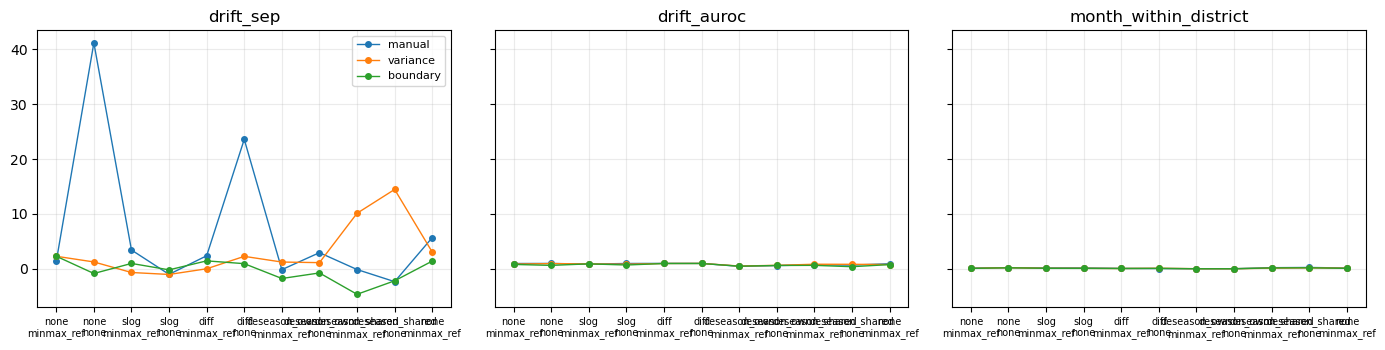

In [15]:
A = RESULTS[RESULTS["window_size"] == PREP_BASE["window_size"]]
for metric in ("drift_sep", "month_within_district", "sil_district"):
    print(f"-- {metric}")
    display(A.pivot_table(index=["transform", "scaling"], columns="strategy",
                          values=metric).round(3))

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for i, metric in enumerate(("drift_sep", "drift_auroc", "month_within_district")):
    for s in STRATEGIES:
        g = A[A["strategy"] == s].set_index(["transform", "scaling"])[metric]
        ax[i].plot(range(len(g)), g.to_numpy(), marker="o", ms=4, lw=1, label=s)
    ax[i].set_xticks(range(len(g)))
    ax[i].set_xticklabels([f"{a}\n{b}" for a, b in g.index], fontsize=7, rotation=0)
    ax[i].set_title(metric); ax[i].grid(alpha=.25)
ax[0].legend(fontsize=8); fig.tight_layout(); plt.show()

## 11. Across worlds

Same grid, reduced to the fixed-geometry block, run on every usable baseline world.
`run_world` is now a thin loop over `run_cell` -- world switching and disk caching both happen
inside it, so re-running this after an interrupted sweep only trains the missing cells.

In [16]:
def run_world(world_row, grid, cap=CAP, rounds=ROUNDS) -> pd.DataFrame:
    rows = []
    for g in grid:
        try:
            rows.append(run_cell(world_row, **g, rounds=rounds, cap=cap))
        except Exception as exc:
            print(f"    {g['strategy']}/{g['transform']}/{g['scaling']} FAILED "
                  f"{type(exc).__name__}: {exc}")
    return pd.DataFrame(rows)


GRID_MULTI = [g for g in GRID if g["prep"] is PREP_BASE]      # drop the geometry block
WORLDS_TO_RUN = usable["dir"].tolist()[:4]                    # trim to taste

all_rows = []
for wd in WORLDS_TO_RUN:
    w = usable[usable["dir"] == wd].iloc[0]
    t0 = time.time()
    print(f"=== {w['tag']} ({w['sim_hash'][:8]}) ===")
    all_rows.append(run_world(w, GRID_MULTI))
    print(f"    {time.time() - t0:.0f}s")

MULTI = pd.concat(all_rows, ignore_index=True)
MULTI = MULTI.merge(
    usable[["sim_hash", "variant", "sim_seed", "consumption_map", "beta", "n_months"]]
    .rename(columns={"sim_hash": "world_id"}), on="world_id", how="left")
print(f"{MULTI['world_id'].nunique()} worlds x {len(GRID_MULTI)} cells = {len(MULTI)} rows  "
      f"(per-cell tables under {SANDBOX}/<world_id>/<cell_id>/)")

=== Cli__LR_LR_LR_LR_LI__baseline (021dcc84) ===


KeyboardInterrupt: 

In [ ]:
piv = MULTI.pivot_table(index=["transform", "scaling"], columns="strategy",
                        values=["drift_sep", "month_within_district"],
                        aggfunc=["mean", "std"]).round(3)
display(piv)

ref = MULTI[(MULTI.strategy == "manual") & (MULTI.transform == "none")
            & (MULTI.scaling == "minmax_ref")].set_index("world_id")
delta = []
for (s, t, k), g in MULTI.groupby(["strategy", "transform", "scaling"]):
    g = g.set_index("world_id")
    common = g.index.intersection(ref.index)
    if len(common) < 2:
        continue
    for metric in ("drift_sep", "drift_auroc", "month_within_district"):
        d = (g.loc[common, metric] - ref.loc[common, metric]).dropna()
        if len(d) < 2:
            continue
        delta.append(dict(strategy=s, transform=t, scaling=k, metric=metric, n=len(d),
                          mean_delta=float(d.mean()), wins=int((d > 0).sum()),
                          se=float(d.std(ddof=1) / np.sqrt(len(d)))))
DELTA = pd.DataFrame(delta)
DELTA["t"] = DELTA["mean_delta"] / DELTA["se"].replace(0, np.nan)
display(DELTA[DELTA.metric == "drift_sep"].sort_values("mean_delta", ascending=False).round(3))

## 12. Latent space explorer

Three panels -- `manual / variance / boundary` -- for one preprocessing combination, with a
**round** slider. Every dropdown cascades over what is actually on disk, so any state you can
reach exists; combinations you never trained show an empty panel. Nothing here trains.

Rounds come from `latents_by_round`; cells trained before SS.7a have no snapshots and fall back
to their final `latent_trajectories` (shown as round `final`). The projection is fitted **per
panel over all of that panel's rounds at once**, so movement between frames is real movement and
not a re-fit -- but each panel keeps its own axes, because the three placements are separately
trained models whose latent bases are unrelated. Compare *structure* across panels, never
position.

In [17]:
def project(Z, method, seed=0):
    Zs = StandardScaler().fit_transform(Z)
    if method == "PCA":
        p = PCA(n_components=2, random_state=seed).fit(Zs)
        sub = "  ".join(f"PC{i+1} {v:.1%}" for i, v in enumerate(p.explained_variance_ratio_))
        return p.transform(Zs), sub
    if method == "t-SNE":
        from sklearn.manifold import TSNE
        perp = min(30, max(5, len(Zs) // 4))
        return TSNE(n_components=2, init="pca", random_state=seed, perplexity=perp).fit_transform(Zs), "t-SNE"
    import umap
    return umap.UMAP(n_components=2, random_state=seed).fit_transform(Zs), "UMAP"


try:
    import umap; HAS_UMAP = True
except Exception:
    HAS_UMAP = False

AttributeError: module 'ml_dtypes' has no attribute 'float8_e4m3b11'

In [ ]:
import re

# ---------------------------------------------------------------- inventory
def _parse_cell_id(cid: str) -> dict | None:
    try:
        strategy, transform, scaling, geom = cid.split("__")
        m = re.fullmatch(r"a(\d+)w(\d+)s(\d+)", geom)
        return dict(strategy=strategy, transform=transform, scaling=scaling,
                    interval_agg_h=int(m[1]), window_size=int(m[2]), step_size=int(m[3]))
    except Exception:
        return None


SPEC_COLS = ["interval_agg_h", "window_size", "step_size", "transform", "scaling"]
METRIC_COLS = ["drift_rank", "drift_sep", "month_within_district"]


def build_inventory() -> pd.DataFrame:
    """Every cell on disk. Registry first; falls back to RESULTS/MULTI in memory."""
    frames = []
    reg = load_registry()
    if len(reg):
        rows = []
        for _, r in reg.iterrows():
            spec = _parse_cell_id(r["cell_id"])
            if spec:
                rows.append({**spec, "world_id": r["world_id"], "cell_id": r["cell_id"],
                             **{k: r.get(k) for k in METRIC_COLS}})
        frames.append(pd.DataFrame(rows))
    for name in ("RESULTS", "MULTI"):                 # in-memory, in case runs.csv lags
        df = globals().get(name)
        if isinstance(df, pd.DataFrame) and len(df) and "cell_id" in df.columns:
            keep = ["strategy", "world_id", "cell_id"] + SPEC_COLS + \
                   [c for c in METRIC_COLS if c in df.columns]
            frames.append(df[[c for c in keep if c in df.columns]].copy())
    if not frames:
        return pd.DataFrame(columns=["strategy", "world_id", "cell_id"] + SPEC_COLS)
    inv = pd.concat(frames, ignore_index=True)
    return inv.drop_duplicates(["world_id", "cell_id"], keep="first")


INV = build_inventory()
if not len(INV):
    print(f"nothing saved under {SANDBOX} and no RESULTS in memory -- run SS.8 first")
else:
    print(f"{len(INV)} cells | {INV['world_id'].nunique()} world(s) | geometries: "
          + ", ".join(f"a{a}w{w}s{s}" for a, w, s in
                      INV[["interval_agg_h", "window_size", "step_size"]]
                      .drop_duplicates().itertuples(index=False)))

_TAGS = dict(zip(usable["sim_hash"], usable["tag"]))
WORLD_OPTIONS = [(_TAGS.get(w, w[:12]), w) for w in sorted(INV["world_id"].unique())] \
    if len(INV) else [("(none)", None)]

FINAL_ROUND_KEY = 10**6          # stands in for "final model, no snapshots"
_TBL: dict = {}
_EMB: dict = {}


def _cell_frame(world_id, cell_id):
    """Per-round snapshots if saved, else the final latents tagged FINAL_ROUND_KEY."""
    key = (world_id, cell_id)
    if key not in _TBL:
        c = load_cell(world_id, cell_id)
        if c is None:
            _TBL[key] = None
        else:
            lbr, lt = c.get("latents_by_round"), c.get("latent_trajectories")
            if lbr is not None and len(lbr):
                _TBL[key] = lbr
            elif lt is not None and len(lt):
                _TBL[key] = lt.assign(round=FINAL_ROUND_KEY)
            else:
                _TBL[key] = None
    return _TBL[key]


def _embed(world_id, cell_id, method, n_pts, seed=0):
    """(frame, embedding, subtitle) with ONE projection fitted over all rounds."""
    key = (world_id, cell_id, method, n_pts)
    if key in _EMB:
        return _EMB[key]
    df = _cell_frame(world_id, cell_id)
    if df is None:
        _EMB[key] = None
        return None
    if n_pts:
        per = max(50, int(n_pts) // max(1, df["round"].nunique()))
        rng = np.random.default_rng(seed)
        df = pd.concat([g.iloc[rng.choice(len(g), min(per, len(g)), replace=False)]
                        for _, g in df.groupby("round")], ignore_index=True)
    f = [c for c in df.columns if c.startswith("f") and c[1:].isdigit()]
    E, sub = project(df[f].to_numpy(float), method)
    _EMB[key] = (df.reset_index(drop=True), E, sub)
    return _EMB[key]


def _round_label(r) -> str:
    return "final" if r == FINAL_ROUND_KEY else ("init (-1)" if r == -1 else f"r{int(r)}")


# ---------------------------------------------------------------- controls
_world  = W.Dropdown(options=WORLD_OPTIONS, value=WORLD_OPTIONS[0][1], description="world")
_agg    = W.Dropdown(description="agg h")
_win    = W.Dropdown(description="window")
_step   = W.Dropdown(description="stride")
_trans  = W.Dropdown(description="transform")
_scal   = W.Dropdown(description="scaling")
_method = W.Dropdown(options=["PCA", "t-SNE"] + (["UMAP"] if HAS_UMAP else []),
                     value="PCA", description="method")
_color  = W.Dropdown(options=["district", "month", "hour", "drift status"],
                     value="district", description="color")
_pts    = W.Dropdown(options=[("2k", 2000), ("4k", 4000), ("8k", 8000), ("all", 0)],
                     value=4000, description="points")
_round  = W.SelectionSlider(options=[("final", FINAL_ROUND_KEY)], value=FINAL_ROUND_KEY,
                            description="round", continuous_update=False,
                            layout=W.Layout(width="80%"))
_status, _plot = W.Output(), W.Output()

CTL = dict(zip(SPEC_COLS, (_agg, _win, _step, _trans, _scal)))
PREFERRED = {"transform": "none", "scaling": "minmax_ref"}     # nicer landing state
_lock = {"busy": False}


def _current():
    prep = dict(interval_agg_h=_agg.value, window_size=_win.value, step_size=_step.value)
    if any(v is None for v in list(prep.values()) + [_trans.value, _scal.value]):
        return None
    return _world.value, prep, _trans.value, _scal.value


def _sync_options(*_):
    """Cascade: each dropdown offers only values that exist given the ones above it."""
    if _lock["busy"] or not len(INV):
        return
    _lock["busy"] = True
    sub = INV[INV.world_id == _world.value]
    for col in SPEC_COLS:
        opts = sorted(sub[col].dropna().unique().tolist())
        ctl = CTL[col]
        val = ctl.value if ctl.value in opts else \
            (PREFERRED[col] if PREFERRED.get(col) in opts else (opts[0] if opts else None))
        ctl.options, ctl.value = opts, val
        sub = sub[sub[col] == val]
    _lock["busy"] = False
    _sync_rounds()


def _sync_rounds(*_):
    """Round options = union of rounds available across the three placements."""
    if _lock["busy"]:
        return
    cur = _current()
    if cur is None:
        return
    wid, prep, t, k = cur
    rounds = set()
    for s in STRATEGIES:
        df = _cell_frame(wid, cell_id_for(s, t, k, prep))
        if df is not None:
            rounds |= set(int(r) for r in df["round"].unique())
    opts = [(_round_label(r), r) for r in sorted(rounds)] or [("final", FINAL_ROUND_KEY)]
    _lock["busy"] = True
    keep = _round.value if _round.value in [v for _, v in opts] else opts[-1][1]
    _round.options, _round.value = opts, keep
    _lock["busy"] = False
    _redraw()


def _redraw(*_):
    if _lock["busy"] or not len(INV):
        return
    cur = _current()
    if cur is None:
        return
    wid, prep, t, k = cur
    sub_inv = INV[INV.world_id == wid]

    with _plot:
        _plot.clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.4))
        panels, missing = [], []
        for ax, s in zip(axes, STRATEGIES):
            cid = cell_id_for(s, t, k, prep)
            emb = _embed(wid, cid, _method.value, _pts.value) \
                if (sub_inv.cell_id == cid).any() else None
            ax.grid(alpha=.2)
            if emb is None:
                missing.append(s)
                ax.set_title(s, fontsize=10)
                ax.text(.5, .5, "not saved", ha="center", va="center", fontsize=9,
                        color="grey", transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([])
                continue
            df, E, proj_sub = emb
            m = (df["round"] == _round.value).to_numpy()
            if not m.any():
                missing.append(f"{s}@{_round_label(_round.value)}")
                ax.set_title(s, fontsize=10)
                ax.text(.5, .5, f"no snapshot at\n{_round_label(_round.value)}",
                        ha="center", va="center", fontsize=9, color="grey",
                        transform=ax.transAxes)
                ax.set_xticks([]); ax.set_yticks([])
                continue
            r = sub_inv[sub_inv.cell_id == cid].iloc[0]
            ax.set_title(f"{s}\nrank {r.drift_rank:.0f}  sep {r.drift_sep:+.2f}  "
                         f"mwd {r.month_within_district:.2f}\n{proj_sub}", fontsize=8)
            ax.set_xlim(E[:, 0].min(), E[:, 0].max())      # frame fixed across rounds
            ax.set_ylim(E[:, 1].min(), E[:, 1].max())
            panels.append((ax, df[m], E[m]))

        cb = None
        if _color.value in ("district", "drift status"):
            key = "district" if _color.value == "district" else "drift_status"
            cats = sorted({c for _, d, _ in panels for c in d[key].unique()})
            cmap = plt.get_cmap("tab10")
            col = {c: cmap(i % 10) for i, c in enumerate(cats)}
            for ax, d, E in panels:
                for c in cats:
                    m = (d[key] == c).to_numpy()
                    if m.any():
                        ax.scatter(E[m, 0], E[m, 1], s=7, alpha=.6, color=col[c],
                                   label=c, linewidths=0)
            if panels:
                panels[0][0].legend(fontsize=7, markerscale=2, loc="best")
        elif panels:
            vals = np.concatenate([d[_color.value].to_numpy() for _, d, _ in panels])
            cmap = "twilight" if _color.value == "hour" else "YlOrBr"
            vmin, vmax = (0, 24) if _color.value == "hour" else (vals.min(), vals.max())
            for ax, d, E in panels:
                cb = ax.scatter(E[:, 0], E[:, 1], c=d[_color.value].to_numpy(), s=7,
                                alpha=.7, cmap=cmap, vmin=vmin, vmax=vmax, linewidths=0)
            fig.colorbar(cb, ax=list(axes)).set_label(_color.value)

        fig.suptitle(f"{_TAGS.get(wid, str(wid)[:12])}  ·  {t} · {k} · "
                     f"agg {prep['interval_agg_h']}h · w{prep['window_size']} · "
                     f"s{prep['step_size']}  ·  {_method.value}  ·  "
                     f"{_round_label(_round.value)}", fontsize=10)
        if cb is None:
            fig.tight_layout(rect=[0, 0, 1, .92])
        plt.show()

    with _status:
        _status.clear_output(wait=True)
        print(f"{len(panels)}/3 placements plotted"
              + (f"  |  missing: {', '.join(missing)}" if missing else ""))


_world.observe(_sync_options, names="value")
for col in SPEC_COLS:
    CTL[col].observe(_sync_options, names="value")     # spec change re-cascades + re-rounds
_round.observe(_redraw, names="value")
for ctl in (_method, _color, _pts):
    ctl.observe(_redraw, names="value")

display(W.VBox([W.HBox([_world, _method, _color, _pts]),
                W.HBox([_agg, _win, _step]), W.HBox([_trans, _scal]),
                _round, _status, _plot]))
_sync_options()

36 cells | 1 world(s) | geometries: a3w84s12, a3w84s24, a4w48s12


## 14. Clustering / similarity -- by phase, by round

This is the `personalization` question, not the dependence one: **which clients look alike**, and
does the answer change as federation proceeds. The pipeline's own helpers do the work
(`_deconfounded_prototypes`, `_drift_signatures`, `_cosine_sim_matrix`, `_cluster`); this section
only chooses the slices and scores the result.

`client_dependence` does not exist for these cells (`dependence_detection` never ran), so the
coupling channel is **inert** and `S_eff == S_fused = w·S_domain + (1-w)·S_drift` -- which is the
non-dependence view we want, and is also what the architecture doc says happens anyway whenever
no pair clears `coupling_q_threshold`.

**Phases.** Similarity is computed on a month window, not on all months pooled:

| phase | months | why |
|---|---|---|
| `init` | first `PHASE_LEN` | commissioning. `consumption_map` describes the world *here*, so this is the only slice where the regime labels are unambiguous |
| `final` | last `PHASE_LEN` | after the mover has drifted. Regime labels are stale for the drift district by construction |
| `all` | everything | the pooled reference, kept for comparison |

Deconfounding is per-month (median common mode across clients within each month), so slicing
months before or after it is identical -- no leakage between phases.

**Read `dri_*` with care in `init`.** `delta_first` is defined relative to each client's own
first month, so in the first few months it is near-zero and `S_drift` is degenerate. In `init`,
`dom_*` is the only interpretable channel; `fus_*` becomes meaningful only later.

Every phase is computed at **every round**, off `prototype_history` -- no retraining, so this runs
on cells trained before SS.7a too.

In [19]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

from fedwater.pipelines.personalization.nodes import (
    _cluster, _cosine_sim_matrix, _deconfounded_prototypes, _drift_signatures,
    build_personalization_clusters)

FCOLS = lambda df: [c for c in df.columns if c.startswith("f") and c[1:].isdigit()]

PHASE_LEN = 3            # months per phase: first PHASE_LEN vs last PHASE_LEN
PHASES = ("init", "final", "all")


def phase_months(months, n: int = PHASE_LEN) -> dict[str, list]:
    ms = sorted(int(m) for m in pd.unique(pd.Series(months)))
    return {"init": ms[:n], "final": ms[-n:], "all": ms}


# --- world metadata -------------------------------------------------------
def world_meta(world_id: str) -> dict:
    """regime map + drift district + first drifted month, per world."""
    row = usable[usable["sim_hash"] == world_id]
    if not len(row):
        return {}
    w = row.iloc[0]
    cmap = w.get("consumption_map") or ""
    regimes = {f"District_{chr(ord('A') + i)}": t
               for i, t in enumerate(cmap.split("_"))} if cmap else {}
    return dict(tag=w["tag"], regimes=regimes, drift_client=w.get("drift_district"),
                drift_start=drift_start(w["dir"], w.get("n_months") or TIME["n_months"]))


WMETA = {wid: world_meta(wid) for wid in INV["world_id"].unique()}


# --- similarity, via the pipeline's own helpers ---------------------------
def _stacks_to_matrix(stacks: dict) -> tuple[list, np.ndarray]:
    """{client: (n_months, D)} -> (clients, flattened rows) on the shared month set."""
    ks = sorted(stacks)
    A = [np.atleast_2d(np.asarray(stacks[k], float)) for k in ks]
    n = min(len(a) for a in A)
    return ks, np.vstack([a[:n].ravel() for a in A])


def _cos(M: np.ndarray) -> np.ndarray:
    """_cosine_sim_matrix if it accepts a client x feature matrix; else local cosine."""
    try:
        S = np.asarray(_cosine_sim_matrix(M), float)
        if S.shape == (len(M), len(M)):
            return S
    except Exception:
        pass
    nrm = np.linalg.norm(M, axis=1, keepdims=True)
    N = M / np.where(nrm > 0, nrm, 1.0)
    return N @ N.T


def _as_stacks(obj, value_col=None) -> dict:
    """Normalize helper output (dict of arrays | tidy frame) to {client: array}."""
    if isinstance(obj, dict):
        return {k: np.asarray(v, float) for k, v in obj.items()}
    df = pd.DataFrame(obj)
    ccol = next(c for c in df.columns if c.lower() in ("client", "district"))
    cols = FCOLS(df) or [value_col or df.columns[-1]]
    return {c: g.sort_values([x for x in ("month",) if x in g.columns] or cols)[cols]
            .to_numpy(float) for c, g in df.groupby(ccol)}


def similarity_channels(ph: pd.DataFrame, ds: pd.DataFrame,
                        months=None) -> tuple[list, np.ndarray, np.ndarray]:
    """(clients, S_domain, S_drift) -- deconfounded prototypes and drift signatures."""
    if months is not None:
        ph = ph[ph["month"].isin(list(months))]
        ds = ds[ds["month"].isin(list(months))]
    ks, M = _stacks_to_matrix(_as_stacks(_deconfounded_prototypes(ph)))
    S_dom = _cos(M)
    try:
        kd, D = _stacks_to_matrix(_as_stacks(_drift_signatures(ds), "delta_first"))
        S_dri = _cos(D) if kd == ks else None
    except Exception:
        S_dri = None
    if S_dri is None:                        # the definition: mean-centered delta_first
        piv = ds.pivot_table(index="client", columns="month", values="delta_first").reindex(ks)
        V = np.nan_to_num(piv.to_numpy(float) - np.nanmean(piv.to_numpy(float), axis=0,
                                                           keepdims=True))
        S_dri = _cos(V)
    return ks, S_dom, S_dri


def cluster_labels(S: np.ndarray, n_hint: int | None = None) -> np.ndarray:
    """_cluster (FINCH) if it takes a similarity matrix; else correlation-distance linkage."""
    for args in ((S,), (S, {})):
        try:
            lab = np.asarray(_cluster(*args)).ravel()
            if len(lab) == len(S):
                return lab
        except Exception:
            continue
    D = np.clip(1.0 - S, 0, None); np.fill_diagonal(D, 0.0)
    k = min(n_hint or 2, len(S) - 1)
    return AgglomerativeClustering(n_clusters=max(2, k), metric="precomputed",
                                   linkage="average").fit_predict(D)


W_DOMAIN = 0.5      # fusion weight; overridden by params:personalization when present
_pers = ART["params"].get("personalization", {}) or {}
W_DOMAIN = float(next((v for k, v in _pers.items()
                       if "domain" in k.lower() and isinstance(v, (int, float))), W_DOMAIN))
print(f"phases {PHASES} (PHASE_LEN={PHASE_LEN})  |  w_domain={W_DOMAIN}")

phases ('init', 'final', 'all') (PHASE_LEN=3)  |  w_domain=0.5


In [20]:
def _offdiag(S):
    return S[~np.eye(len(S), dtype=bool)]


def similarity_scores(ks, S, regimes: dict, drift_client=None, prefix="") -> dict:
    """Structure in the similarity matrix itself -- no clustering, no ground truth in the loop."""
    off = _offdiag(S)
    out = {f"{prefix}mean_offdiag": float(np.nanmean(off)),
           f"{prefix}sd_offdiag": float(np.nanstd(off)),
           f"{prefix}collapsed": bool(np.nanmean(off) > 0.999 or np.nanstd(off) < 1e-4)}
    if regimes:
        lab = np.array([regimes.get(k, "?") for k in ks])
        same = (lab[:, None] == lab[None, :]) & ~np.eye(len(ks), dtype=bool)
        diff = (lab[:, None] != lab[None, :])
        if same.any() and diff.any():
            out[f"{prefix}regime_gap"] = float(np.nanmean(S[same]) - np.nanmean(S[diff]))
    if drift_client in ks:
        i = ks.index(drift_client)
        m = ~np.eye(len(ks), dtype=bool)
        rest = m.copy(); rest[i, :] = rest[:, i] = False
        out[f"{prefix}drift_isolation"] = float(np.nanmean(S[i][m[i]]) - np.nanmean(S[rest]))
    return out


def _fl_for(spec: dict) -> dict:
    """Reconstruct the fl config a saved cell was trained with (for compute_drift_signals)."""
    fl = copy.deepcopy(FL_BASE)
    fl["preprocessing"].update(spec.get("prep", {}) or {})
    if spec.get("rounds"):
        fl["training"]["rounds"] = spec["rounds"]
    return fl


def _drift_for_round(ph_r: pd.DataFrame, fl: dict) -> pd.DataFrame:
    """delta_first for ONE round. compute_drift_signals verbatim; if it needs the full
    history, fall back to cosine distance of each month's prototype to the first."""
    try:
        ds = compute_drift_signals(ph_r, fl)
        if len(ds) and {"client", "month", "delta_first"} <= set(ds.columns):
            return ds
    except Exception:
        pass
    f, rows = FCOLS(ph_r), []
    for c, g in ph_r.groupby("client"):
        g = g.sort_values("month")
        V = g[f].to_numpy(float)
        ref = V[0]
        den = np.linalg.norm(V, axis=1) * (np.linalg.norm(ref) or 1.0)
        cos = np.divide((V * ref).sum(1), np.where(den > 0, den, np.nan))
        rows.append(pd.DataFrame({"client": c, "month": g["month"].to_numpy(),
                                  "delta_first": 1.0 - cos}))
    return pd.concat(rows, ignore_index=True)


def analyse_cell_phases(world_id: str, cell_id: str, save=True) -> tuple:
    """Similarity + clustering at every (round, phase). Returns (scores, labels, pairs)."""
    c = load_cell(world_id, cell_id)
    if c is None or c["prototype_history"] is None:
        return None, None, None
    ph_all = c["prototype_history"]
    if "round" not in ph_all.columns or "client" not in ph_all.columns:
        return None, None, None

    meta = WMETA.get(world_id, {})
    regimes, dc = meta.get("regimes", {}), meta.get("drift_client")
    n_hint = len(set(regimes.values())) if regimes else 2
    fl = _fl_for(c["spec"])
    spec = _parse_cell_id(cell_id) or {}
    windows = phase_months(ph_all["month"])
    base = dict(world_id=world_id, cell_id=cell_id, tag=meta.get("tag"), **spec)

    scores, labels, pairs = [], [], []
    for r, ph_r in ph_all.groupby("round"):
        if ph_r["client"].nunique() < 3:
            continue
        try:
            ds_r = _drift_for_round(ph_r, fl)
        except Exception as exc:
            scores.append({**base, "round": int(r), "error": f"{type(exc).__name__}: {exc}"})
            continue
        for phase in PHASES:
            months = windows[phase]
            if len(months) < 1:
                continue
            try:
                ks, S_dom, S_dri = similarity_channels(ph_r, ds_r, months=months)
                S_fus = W_DOMAIN * S_dom + (1 - W_DOMAIN) * S_dri
                row = {**base, "round": int(r), "phase": phase, "n_months": len(months),
                       "n_clients": len(ks),
                       **similarity_scores(ks, S_dom, regimes, dc, "dom_"),
                       **similarity_scores(ks, S_dri, regimes, dc, "dri_"),
                       **similarity_scores(ks, S_fus, regimes, dc, "fus_")}
                lab_row = {"client": ks}
                for name, S in (("dom", S_dom), ("dri", S_dri), ("fus", S_fus)):
                    lab = cluster_labels(S, n_hint)
                    lab_row[f"cluster_{name}"] = lab
                    row[f"{name}_n_clusters"] = int(len(set(lab)))
                    if regimes:
                        row[f"{name}_ari_regime"] = float(adjusted_rand_score(
                            [regimes.get(k, "?") for k in ks], lab))
                    if dc in ks:
                        row[f"{name}_drift_singleton"] = bool(
                            (lab == lab[ks.index(dc)]).sum() == 1)
                scores.append(row)
                labels.append(pd.DataFrame({**lab_row, "round": int(r), "phase": phase,
                                            "world_id": world_id, "cell_id": cell_id}))
                pairs += [dict(**base, round=int(r), phase=phase, client_a=a, client_b=b,
                               s_domain=S_dom[i, j], s_drift=S_dri[i, j], s_fused=S_fus[i, j])
                          for i, a in enumerate(ks) for j, b in enumerate(ks) if i < j]
            except Exception as exc:
                scores.append({**base, "round": int(r), "phase": phase,
                               "error": f"{type(exc).__name__}: {exc}"})

    S_df = pd.DataFrame(scores)
    L_df = pd.concat(labels, ignore_index=True) if labels else None
    P_df = pd.DataFrame(pairs) if pairs else None
    if save and len(S_df):
        save_analysis(world_id, cell_id, clusters_by_phase=L_df, similarity_by_phase=P_df)
    return S_df, L_df, P_df


sc_frames, lab_frames, skipped = [], [], []
for _, r in INV.drop_duplicates(["world_id", "cell_id"]).iterrows():
    S_df, L_df, _ = analyse_cell_phases(r["world_id"], r["cell_id"])
    if S_df is None or not len(S_df):
        skipped.append({"cell_id": r["cell_id"], "why": "no prototype_history / no round col"})
        continue
    sc_frames.append(S_df)
    if L_df is not None:
        lab_frames.append(L_df)

CLUSTERS_PHASES = pd.concat(sc_frames, ignore_index=True) if sc_frames else pd.DataFrame()
LABELS_PHASES = pd.concat(lab_frames, ignore_index=True) if lab_frames else pd.DataFrame()
if len(CLUSTERS_PHASES):
    CLUSTERS_PHASES.to_csv(SANDBOX / "clustering_by_phase.csv", index=False)

# final-round pooled view, for continuity with the SS.10 tables
CLUSTERS = pd.DataFrame()
if len(CLUSTERS_PHASES) and "phase" in CLUSTERS_PHASES:
    ok = CLUSTERS_PHASES[CLUSTERS_PHASES.get("error").isna()] \
        if "error" in CLUSTERS_PHASES else CLUSTERS_PHASES
    if len(ok):
        CLUSTERS = ok[(ok["round"] == ok["round"].max()) & (ok["phase"] == "all")].copy()

print(f"{len(CLUSTERS_PHASES)} (cell, round, phase) rows | "
      f"{CLUSTERS_PHASES['cell_id'].nunique() if len(CLUSTERS_PHASES) else 0} cells | "
      f"rounds {sorted(CLUSTERS_PHASES['round'].unique())[:6] if len(CLUSTERS_PHASES) else []}"
      f"...  ->  {SANDBOX/'clustering_by_phase.csv'}")
if skipped:
    display(pd.DataFrame(skipped).head(5))
if "error" in CLUSTERS_PHASES.columns:
    err = CLUSTERS_PHASES[CLUSTERS_PHASES["error"].notna()]
    if len(err):
        print(f"{len(err)} failed (round, phase) slices"); display(err.head(3))
CLUSTERS_PHASES.head(6).round(3)

1620 (cell, round, phase) rows | 36 cells | rounds [0, 1, 2, 3, 4, 5]...  ->  C:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\prospection\latent_sandbox\clustering_by_phase.csv


,world_id,cell_id,tag,strategy,transform,scaling,interval_agg_h,window_size,step_size,round,...,fus_drift_isolation,dom_n_clusters,dom_ari_regime,dom_drift_singleton,dri_n_clusters,dri_ari_regime,dri_drift_singleton,fus_n_clusters,fus_ari_regime,fus_drift_singleton
0,e0f8c48c1006,manual__none__minmax_ref__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,manual,none,minmax_ref,3,84,12,0,...,-0.141,2,0.167,False,2,0.231,False,2,0.231,False
1,e0f8c48c1006,manual__none__minmax_ref__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,manual,none,minmax_ref,3,84,12,0,...,-0.477,2,-0.250,False,2,-0.154,True,2,-0.154,True
2,e0f8c48c1006,manual__none__minmax_ref__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,manual,none,minmax_ref,3,84,12,0,...,-0.140,2,-0.250,False,2,-0.250,False,2,-0.250,False
3,e0f8c48c1006,manual__none__minmax_ref__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,manual,none,minmax_ref,3,84,12,1,...,-0.180,2,-0.250,False,2,0.231,False,2,-0.154,True
4,e0f8c48c1006,manual__none__minmax_ref__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,manual,none,minmax_ref,3,84,12,1,...,-0.475,2,-0.250,False,2,-0.154,True,2,-0.154,True
5,e0f8c48c1006,manual__none__minmax_ref__a3w84s12,Dli__LI_LR_LR_LR_LI__baseline,manual,none,minmax_ref,3,84,12,1,...,-0.183,2,-0.250,False,2,-0.154,True,2,-0.250,False


## 15. Migration -- does the mover change cluster?

The static partitions are weak evidence: with 5 clients and 2 regime tokens there are only 10
pairs, and a spurious similarity has a decent chance of ordering them correctly. A **crossing** is
much harder to fake -- a signal with no relation to the physics has no reason to move the drift
district specifically, and leave the other four where they were.

Per (cell, round) we compare the `init` and `final` clusterings and record:

| column | meaning |
|---|---|
| `ari_init_final` | agreement between the two phases; low = the partition rearranged |
| `n_migrated` | clients whose co-membership set changed (label-invariant, so relabelling is not a migration) |
| `drift_migrated` | did the true drift district move |
| `clean_crossing` | `drift_migrated` **and** `n_migrated == 1` -- the mover moved and nobody else did |

`clean_crossing` is the claim to look for; everything else is context for why it did or did not
happen.

In [21]:
def _partners(clients, lab) -> dict:
    """client -> frozenset of its co-members. Label-invariant."""
    lab = np.asarray(lab)
    return {c: frozenset(np.asarray(clients)[(lab == lab[i])]) - {c}
            for i, c in enumerate(clients)}


def migration_table(labels: pd.DataFrame, channel="fus") -> pd.DataFrame:
    """init -> final cluster crossings, per (world, cell, round)."""
    col = f"cluster_{channel}"
    if not len(labels) or col not in labels.columns:
        return pd.DataFrame()
    rows = []
    for (wid, cid, r), g in labels.groupby(["world_id", "cell_id", "round"]):
        gi, gf = g[g.phase == "init"], g[g.phase == "final"]
        if not len(gi) or not len(gf):
            continue
        gi, gf = gi.sort_values("client"), gf.sort_values("client")
        common = sorted(set(gi["client"]) & set(gf["client"]))
        if len(common) < 3:
            continue
        gi, gf = gi[gi.client.isin(common)], gf[gf.client.isin(common)]
        Pi = _partners(gi["client"].tolist(), gi[col].to_numpy())
        Pf = _partners(gf["client"].tolist(), gf[col].to_numpy())
        moved = [c for c in common if Pi[c] != Pf[c]]
        dc = WMETA.get(wid, {}).get("drift_client")
        rows.append({"world_id": wid, "cell_id": cid, "tag": WMETA.get(wid, {}).get("tag"),
                     **(_parse_cell_id(cid) or {}), "round": int(r), "channel": channel,
                     "ari_init_final": float(adjusted_rand_score(gi[col], gf[col])),
                     "n_clusters_init": int(gi[col].nunique()),
                     "n_clusters_final": int(gf[col].nunique()),
                     "n_migrated": len(moved), "migrated": ",".join(moved),
                     "drift_client": dc,
                     "drift_migrated": bool(dc in moved),
                     "clean_crossing": bool(dc in moved and len(moved) == 1)})
    return pd.DataFrame(rows)


MIGRATION = pd.concat([migration_table(LABELS_PHASES, ch) for ch in ("dom", "fus")],
                      ignore_index=True) if len(LABELS_PHASES) else pd.DataFrame()
if len(MIGRATION):
    MIGRATION.to_csv(SANDBOX / "migration.csv", index=False)
    FINAL_R = MIGRATION["round"].max()
    print(f"{len(MIGRATION)} (cell, round, channel) rows  ->  {SANDBOX/'migration.csv'}")

    print("\n== final round: clean crossings by preprocessing (domain channel) ==")
    mf = MIGRATION[(MIGRATION["round"] == FINAL_R) & (MIGRATION.channel == "dom")]
    display(mf.pivot_table(index=["transform", "scaling"], columns="strategy",
                           values="clean_crossing", aggfunc="mean").round(2))

    print("== cells with a clean crossing at the final round ==")
    display(mf[mf.clean_crossing][["strategy", "transform", "scaling", "tag",
                                   "ari_init_final", "n_clusters_init", "n_clusters_final",
                                   "migrated"]].head(12))

    print("== migration rate over rounds (fused channel) ==")
    display(MIGRATION[MIGRATION.channel == "fus"]
            .pivot_table(index="round", values=["drift_migrated", "clean_crossing",
                                                "ari_init_final"], aggfunc="mean")
            .round(3).tail(8))
else:
    print("no labels -- run SS.14 first")

1080 (cell, round, channel) rows  ->  C:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\prospection\latent_sandbox\migration.csv

== final round: clean crossings by preprocessing (domain channel) ==


strategy                    boundary  manual  variance
transform       scaling                               
deseason_own    minmax_ref       0.0     0.0       0.0
                none             0.0     0.0       0.0
deseason_shared minmax_ref       0.0     0.0       0.0
                none             0.0     0.0       0.0
diff            minmax_ref       0.0     0.0       0.0
                none             0.0     0.0       0.0
none            minmax_ref       0.0     0.0       0.0
                none             0.0     0.0       0.0
slog            minmax_ref       0.0     0.0       0.0
                none             0.0     0.0       0.0

== cells with a clean crossing at the final round ==


,strategy,transform,scaling,tag,ari_init_final,n_clusters_init,n_clusters_final,migrated


== migration rate over rounds (fused channel) ==


,ari_init_final,clean_crossing,drift_migrated
round,,,
7,0.156,0.0,0.806
8,0.140,0.0,0.833
9,0.202,0.0,0.806
10,0.206,0.0,0.778
11,0.171,0.0,0.861
12,0.218,0.0,0.778
13,0.267,0.0,0.722
14,0.261,0.0,0.750


## 16. Clustering figures and the compiled read

== ARI vs regime, final round, by phase (fused) ==


phase                         all  final   init
transform       scaling                        
deseason_own    minmax_ref  0.049  0.209  0.028
                none       -0.058  0.071 -0.186
deseason_shared minmax_ref -0.250  0.199 -0.090
                none        0.060 -0.047  0.722
diff            minmax_ref  0.466  0.028  0.444
                none        0.338  0.199  0.306
none            minmax_ref -0.170 -0.149 -0.042
                none        0.209  0.466  0.167
slog            minmax_ref -0.250 -0.250 -0.250
                none       -0.111  0.199  0.049

== init vs final phase, domain channel: within- minus between-regime similarity ==


phase                           all                    final                     init                
strategy                   boundary manual variance boundary manual variance boundary manual variance
transform       scaling                                                                              
deseason_own    minmax_ref    0.003 -0.271   -0.117    0.024 -0.238   -0.206    0.006 -0.305   -0.164
                none          0.089  0.095    0.056   -0.012  0.156   -0.117   -0.049  0.087    0.027
deseason_shared minmax_ref   -0.067 -0.058   -0.334   -0.046 -0.180   -0.443   -0.091 -0.111   -0.325
                none         -0.200  0.295    0.496   -0.206  0.295    0.495   -0.203  0.294    0.496
diff            minmax_ref    0.479  0.239    0.355    0.487  0.370    0.054    0.429 -0.053    0.529
                none         -0.134  0.485    0.084   -0.224  0.529    0.004   -0.007  0.422    0.140
none            minmax_ref   -0.014 -0.152    0.223   -0.074 -0.176    0.316   -0.076  0.124   -0.039
                none          0.040  0.292    0.476    0.029  0.306    0.490    0.052  0.261    0.431
slog            minmax_ref   -0.064 -0.459    0.192   -0.018 -0.497    0.449   -0.098 -0.470   -0.279
                none          0.420  0.097    0.163    0.426  0.093    0.216    0.418  0.103    0.128

== did federation build the structure? (init phase, first vs last round) ==


dom_ari_regime_final_round  dom_regime_gap_final_round  dom_ari_regime_first_round  dom_regime_gap_first_round  ari_gain
strategy transform       scaling                                                                                                                             
variance diff            minmax_ref                       1.000                       0.529                       0.167                       0.475     0.833
manual   deseason_shared none                             1.000                       0.294                       0.167                       0.179     0.833
boundary none            none                             0.167                       0.052                      -0.250                      -0.239     0.417
         slog            none                             0.167                       0.418                      -0.250                      -0.125     0.417
variance deseason_own    minmax_ref                       0.167                      -0.164                      -0.250                      -0.334     0.417
manual   deseason_own    none                             0.167                       0.087                      -0.154                       0.231     0.321
boundary deseason_shared none                            -0.154                      -0.203                      -0.250                      -0.300     0.096
variance deseason_own    none                            -0.154                       0.027                      -0.250                      -0.068     0.096
boundary deseason_own    minmax_ref                      -0.250                       0.006                      -0.250                      -0.207     0.000
manual   none            none                             0.167                       0.261                       0.167                       0.213     0.000


collapsed similarity matrices: 0/1485 slices


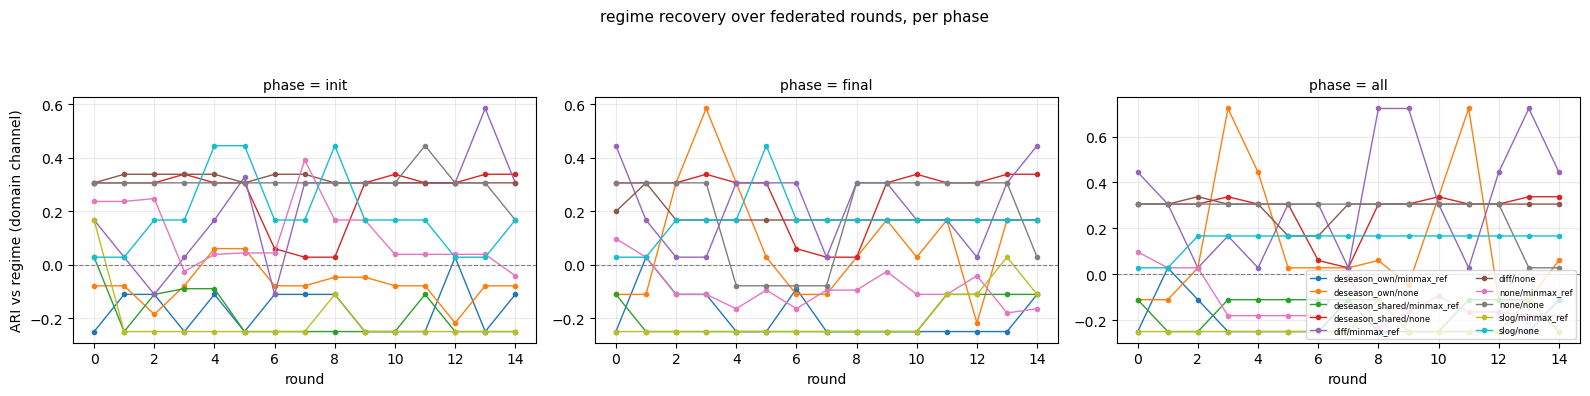

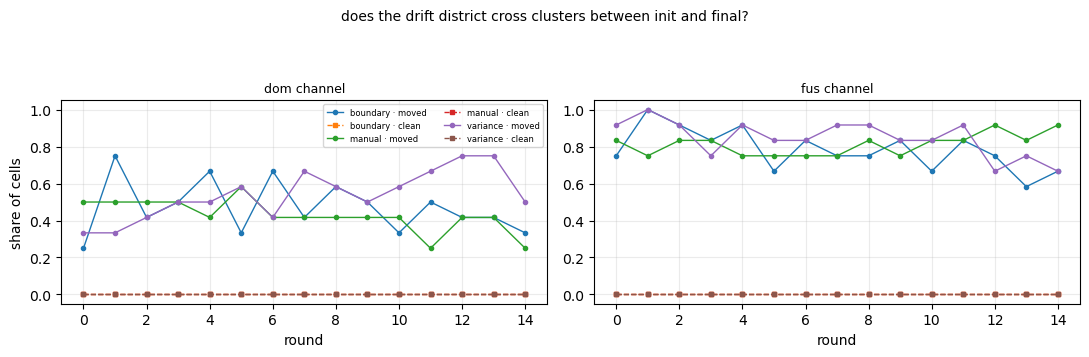

In [22]:
CP = CLUSTERS_PHASES
CP = CP[CP["error"].isna()] if "error" in CP.columns else CP
CP = CP[CP["window_size"] == PREP_BASE["window_size"]]          # fixed-geometry block
FINAL_R = CP["round"].max()

print("== ARI vs regime, final round, by phase (fused) ==")
display(CP[CP["round"] == FINAL_R]
        .pivot_table(index=["transform", "scaling"], columns=["phase"],
                     values="fus_ari_regime", aggfunc="mean").round(3))

print("== init vs final phase, domain channel: within- minus between-regime similarity ==")
display(CP[CP["round"] == FINAL_R]
        .pivot_table(index=["transform", "scaling"], columns=["phase", "strategy"],
                     values="dom_regime_gap", aggfunc="mean").round(3))

print("== did federation build the structure? (init phase, first vs last round) ==")
ini = CP[(CP.phase == "init") & (CP["round"] == CP["round"].min())]
fin = CP[(CP.phase == "init") & (CP["round"] == FINAL_R)]
keys = ["strategy", "transform", "scaling"]
cmp = (fin.groupby(keys)[["dom_ari_regime", "dom_regime_gap"]].mean()
       .join(ini.groupby(keys)[["dom_ari_regime", "dom_regime_gap"]].mean(),
             lsuffix="_final_round", rsuffix="_first_round"))
cmp["ari_gain"] = cmp["dom_ari_regime_final_round"] - cmp["dom_ari_regime_first_round"]
display(cmp.sort_values("ari_gain", ascending=False).round(3).head(10))

deg = CP[CP[["dom_collapsed", "fus_collapsed"]].any(axis=1)]
print(f"\ncollapsed similarity matrices: {len(deg)}/{len(CP)} slices"
      + (f"  |  worst: {deg.groupby(['transform','scaling']).size().idxmax()}" if len(deg) else ""))

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)
for ax, phase in zip(axes, PHASES):
    g_all = CP[CP.phase == phase]
    for (t, k), g in g_all.groupby(["transform", "scaling"]):
        s = g.groupby("round")["dom_ari_regime"].mean()
        ax.plot(s.index, s.to_numpy(), marker="o", ms=3, lw=1, label=f"{t}/{k}")
    ax.axhline(0, ls="--", c="grey", lw=.8)
    ax.set_title(f"phase = {phase}", fontsize=10); ax.set_xlabel("round"); ax.grid(alpha=.25)
axes[0].set_ylabel("ARI vs regime (domain channel)")
axes[-1].legend(fontsize=6, ncol=2, loc="lower right")
fig.suptitle("regime recovery over federated rounds, per phase", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, .92]); plt.show()

if len(MIGRATION):
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    for ch, a in zip(("dom", "fus"), ax):
        g_all = MIGRATION[MIGRATION.channel == ch]
        for s, g in g_all.groupby("strategy"):
            t = g.groupby("round")[["drift_migrated", "clean_crossing"]].mean()
            a.plot(t.index, t["drift_migrated"], marker="o", ms=3, lw=1, label=f"{s} · moved")
            a.plot(t.index, t["clean_crossing"], marker="s", ms=3, lw=1, ls="--",
                   label=f"{s} · clean")
        a.set_title(f"{ch} channel", fontsize=9); a.set_xlabel("round")
        a.set_ylim(-.05, 1.05); a.grid(alpha=.25)
    ax[0].set_ylabel("share of cells"); ax[0].legend(fontsize=6, ncol=2)
    fig.suptitle("does the drift district cross clusters between init and final?", fontsize=10)
    fig.tight_layout(rect=[0, 0, 1, .9]); plt.show()

In [23]:
def validate_node(world_id, cell_id) -> str:
    """Run the real personalization node with an inert dependence channel, to confirm our
    hand-composed S_fused matches what the pipeline would build."""
    c = load_cell(world_id, cell_id)
    ph, ds = c["prototype_history"], c["drift_signals"]
    clients = sorted(ph["client"].unique())
    empty_dep = pd.DataFrame([
        dict(district_a=a, district_b=b, level="T", method="rv", statistic=0.0,
             p_value=1.0, q_value=1.0)
        for i, a in enumerate(clients) for b in clients[i + 1:]])
    last = "no attempt"
    for params in (ART["params"].get("personalization", {}), {}, None):
        try:
            res = build_personalization_clusters(ph, ds, empty_dep, params) if params is not None \
                else build_personalization_clusters(ph, ds, empty_dep)
            sm = next(x for x in (res if isinstance(res, tuple) else (res,))
                      if isinstance(x, pd.DataFrame)
                      and any("s_" in col or "sim" in col.lower() for col in x.columns))
            return f"node ran; similarity frame {sm.shape}, cols {list(sm.columns)[:6]}"
        except Exception as exc:
            last = f"{type(exc).__name__}: {exc}"
    return f"node not callable here ({last}) -- using the helper composition in SS.14"


if len(INV):
    print(validate_node(INV.iloc[0]["world_id"], INV.iloc[0]["cell_id"]))

node not callable here (TypeError: build_personalization_clusters() missing 2 required positional arguments: 'fl' and 'seed') -- using the helper composition in SS.14


In [26]:
## 16b. Is the ARI flat because nothing moves, or because ARI can't see it?

CP = CLUSTERS_PHASES
CP = CP[CP["error"].isna()] if "error" in CP.columns else CP
CP = CP[CP["window_size"] == PREP_BASE["window_size"]]

def _spread(g, col):
    v = g[col].dropna()
    return dict(mean=float(v.mean()), rng=float(v.max() - v.min()),
                sd=float(v.std(ddof=0)), n_unique=int(v.round(6).nunique()))


rows = []
for (t, k, ph), g in CP.groupby(["transform", "scaling", "phase"]):
    g = g.sort_values("round")
    r = g["round"].to_numpy(float)
    rec = {"transform": t, "scaling": k, "phase": ph, "n_rounds": g["round"].nunique()}
    for col, tag in (("dom_mean_offdiag", "sim_mean"), ("dom_sd_offdiag", "sim_sd"),
                     ("dom_regime_gap", "gap"), ("dom_ari_regime", "ari")):
        if col not in g:
            continue
        s = _spread(g, col)
        rec.update({f"{tag}_mean": s["mean"], f"{tag}_rng": s["rng"],
                    f"{tag}_uniq": s["n_unique"]})
        v = g[col].to_numpy(float)
        ok = np.isfinite(v)
        rec[f"{tag}_trend_r"] = (float(np.corrcoef(r[ok], v[ok])[0, 1])
                                 if ok.sum() > 2 and np.std(v[ok]) > 0 else np.nan)
    rec["collapsed_any"] = bool(g.get("dom_collapsed", pd.Series(False)).any())
    rec["n_clusters_mode"] = (int(g["dom_n_clusters"].mode().iloc[0])
                              if "dom_n_clusters" in g and len(g["dom_n_clusters"].dropna())
                              else np.nan)
    rows.append(rec)

DIAG = pd.DataFrame(rows)
print("VERDICT per (transform, scaling, phase):")
print("  sim_rng ~ 0  and ari_rng ~ 0        -> nothing moves; the round axis is genuinely flat")
print("  sim_rng >  0  and ari_uniq <= 2     -> QUANTIZATION: similarity drifts, ARI can't resolve")
print("  collapsed_any                       -> saturated matrix; ignore its ARI entirely\n")
DIAG["verdict"] = np.where(
    DIAG["collapsed_any"], "collapsed",
    np.where((DIAG["sim_mean_rng"] > 1e-3) & (DIAG["ari_uniq"] <= 2), "quantization",
             np.where(DIAG["sim_mean_rng"] <= 1e-3, "static", "moves")))
display(DIAG[["transform", "scaling", "phase", "sim_mean_mean", "sim_mean_rng",
              "sim_sd_mean", "gap_rng", "gap_trend_r", "ari_rng", "ari_uniq",
              "n_clusters_mode", "verdict"]].round(4)
        .sort_values(["phase", "verdict"]))

print("\n== verdict counts ==")
display(DIAG.groupby(["phase", "verdict"]).size().unstack(fill_value=0))

VERDICT per (transform, scaling, phase):
  sim_rng ~ 0  and ari_rng ~ 0        -> nothing moves; the round axis is genuinely flat
  sim_rng >  0  and ari_uniq <= 2     -> QUANTIZATION: similarity drifts, ARI can't resolve
  collapsed_any                       -> saturated matrix; ignore its ARI entirely



,transform,scaling,phase,sim_mean_mean,sim_mean_rng,sim_sd_mean,gap_rng,gap_trend_r,ari_rng,ari_uniq,n_clusters_mode,verdict
3,deseason_own,none,all,-0.1188,0.0681,0.1800,0.4140,-0.2868,1.2500,4,2,moves
9,deseason_shared,none,all,-0.0460,0.1576,0.2830,0.8533,0.0757,1.2500,4,2,moves
12,diff,minmax_ref,all,-0.1245,0.1129,0.3182,0.8323,-0.0156,1.2500,3,2,moves
15,diff,none,all,-0.0973,0.0488,0.3064,0.7664,-0.0236,1.2500,4,2,moves
18,none,minmax_ref,all,-0.1160,0.1370,0.3530,0.7995,-0.0719,1.2500,4,2,moves
21,none,none,all,-0.0523,0.2267,0.3266,0.7694,0.1331,1.2500,3,2,moves
0,deseason_own,minmax_ref,all,-0.1297,0.0534,0.3116,0.3252,-0.0139,0.4167,2,2,quantization
6,deseason_shared,minmax_ref,all,-0.1222,0.0466,0.3617,0.5022,0.1220,0.4167,2,2,quantization
24,slog,minmax_ref,all,-0.1055,0.0908,0.4141,0.7256,0.0933,0.4167,2,2,quantization
27,slog,none,all,-0.1172,0.1309,0.3759,0.5885,0.0514,0.4167,2,2,quantization



== verdict counts ==


verdict,moves,quantization
phase,,
all,6,4
final,8,2
init,9,1


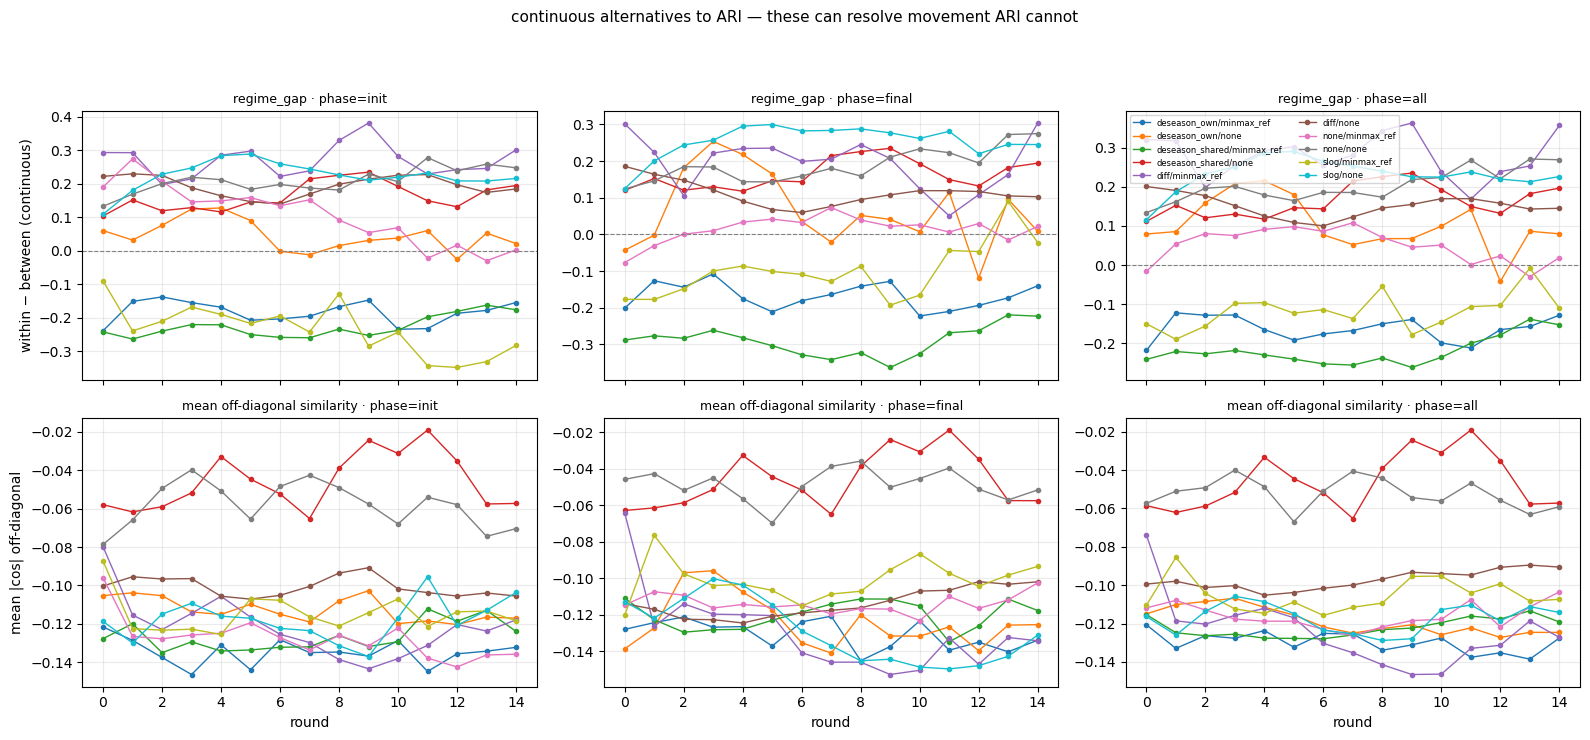

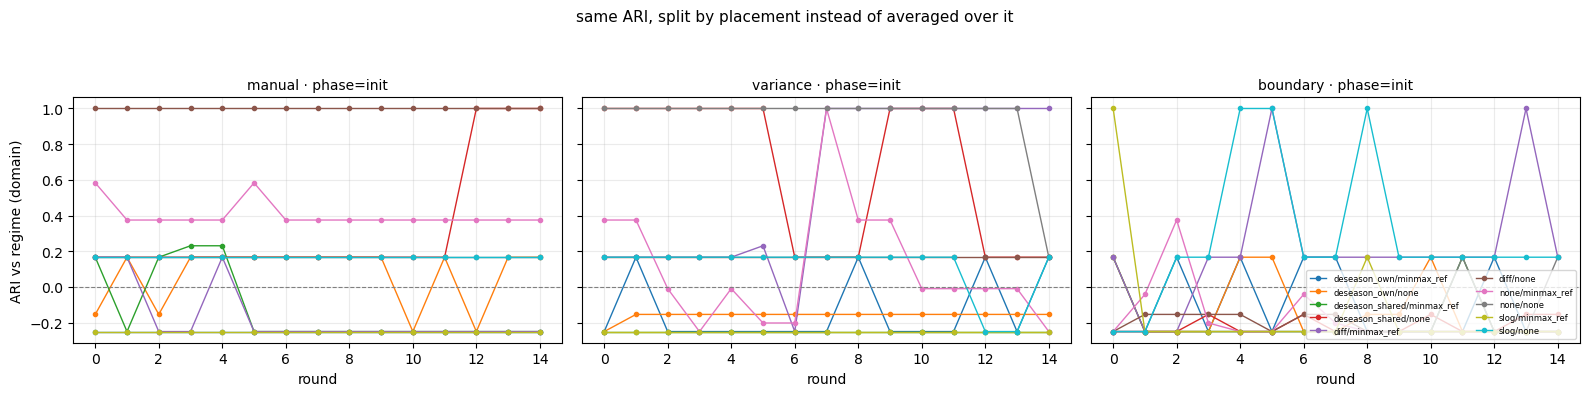

In [ ]:
# --- continuous metric over rounds, and ARI faceted by strategy ---------------
fig, axes = plt.subplots(2, 3, figsize=(16, 7.5), sharex=True)
for j, ph in enumerate(PHASES):
    g_all = CP[CP.phase == ph]
    for (t, k), g in g_all.groupby(["transform", "scaling"]):
        s = g.groupby("round")["dom_regime_gap"].mean()
        axes[0, j].plot(s.index, s.to_numpy(), marker="o", ms=3, lw=1, label=f"{t}/{k}")
        s2 = g.groupby("round")["dom_mean_offdiag"].mean()
        axes[1, j].plot(s2.index, s2.to_numpy(), marker="o", ms=3, lw=1)
    axes[0, j].axhline(0, ls="--", c="grey", lw=.8)
    axes[0, j].set_title(f"regime_gap · phase={ph}", fontsize=9)
    axes[1, j].set_title(f"mean off-diagonal similarity · phase={ph}", fontsize=9)
    for i in (0, 1):
        axes[i, j].grid(alpha=.25)
    axes[1, j].set_xlabel("round")
axes[0, 0].set_ylabel("within − between (continuous)")
axes[1, 0].set_ylabel("mean |cos| off-diagonal")
axes[0, -1].legend(fontsize=6, ncol=2, loc="best")
fig.suptitle("continuous alternatives to ARI — these can resolve movement ARI cannot", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, .93]); plt.show()

In [28]:
# --- why does everyone migrate? global shift vs unstable clustering ----------
mig_rows = []
for (wid, cid), g in LABELS_PHASES.groupby(["world_id", "cell_id"]):
    sim = _read_table(SANDBOX / wid / cid / "similarity_by_phase")
    if sim is None:
        continue
    for r, gr in sim.groupby("round"):
        i, f = gr[gr.phase == "init"], gr[gr.phase == "final"]
        if not len(i) or not len(f):
            continue
        key = ["client_a", "client_b"]
        m = i.merge(f, on=key, suffixes=("_i", "_f"))
        if len(m) < 3:
            continue
        mig_rows.append({"world_id": wid, "cell_id": cid, **(_parse_cell_id(cid) or {}),
                         "round": int(r),
                         "mean_shift": float((m.s_domain_f - m.s_domain_i).mean()),
                         "rank_stability": float(m[["s_domain_i", "s_domain_f"]]
                                                 .corr(method="spearman").iloc[0, 1]),
                         "spread_i": float(m.s_domain_i.std(ddof=0)),
                         "spread_f": float(m.s_domain_f.std(ddof=0))})
MIGDIAG = pd.DataFrame(mig_rows)
if len(MIGDIAG):
    print("rank_stability = Spearman of the 10 pair similarities, init vs final")
    print("  high (>0.8) + big mean_shift -> GLOBAL SHIFT: every pair moved together,")
    print("     the ORDER is preserved, so migration is a threshold artifact")
    print("  low (<0.3)                   -> the ordering itself rearranged: real restructuring")
    print("  tiny spread_i/spread_f       -> near-ties; labels flip on nothing\n")
    display(MIGDIAG[MIGDIAG["round"] == MIGDIAG["round"].max()]
            .groupby(["transform", "scaling"])[["mean_shift", "rank_stability",
                                                "spread_i", "spread_f"]]
            .mean().round(4))
else:
    print("no similarity_by_phase tables -- re-run SS.14 (it saves them)")

rank_stability = Spearman of the 10 pair similarities, init vs final
  high (>0.8) + big mean_shift -> GLOBAL SHIFT: every pair moved together,
     the ORDER is preserved, so migration is a threshold artifact
  low (<0.3)                   -> the ordering itself rearranged: real restructuring
  tiny spread_i/spread_f       -> near-ties; labels flip on nothing



mean_shift  rank_stability  spread_i  spread_f
transform       scaling                                                   
deseason_own    minmax_ref     -0.0018          0.9152    0.3700    0.3434
                none           -0.0085          0.2606    0.1701    0.1607
deseason_shared minmax_ref      0.0062          0.9030    0.4670    0.4389
                none           -0.0003          1.0000    0.3098    0.3103
diff            minmax_ref     -0.0164          0.5192    0.3454    0.3359
                none            0.0035          0.7212    0.3084    0.3160
none            minmax_ref      0.0230          0.5569    0.4828    0.3577
                none            0.0187          0.9717    0.3342    0.3476
slog            minmax_ref      0.0248          0.3657    0.4777    0.5072
                none           -0.0276          0.9192    0.3805    0.4201

In [29]:
def migration_continuous(channel="s_domain") -> pd.DataFrame:
    """Per-client change in mean similarity to everyone else, init -> final, z-scored
    across clients. No clustering, no cut point: does the mover move MORE than the rest?"""
    rows = []
    for (wid, cid), _ in LABELS_PHASES.groupby(["world_id", "cell_id"]):
        sim = _read_table(SANDBOX / wid / cid / "similarity_by_phase")
        if sim is None:
            continue
        dc = WMETA.get(wid, {}).get("drift_client")
        for r, gr in sim.groupby("round"):
            d = {}
            for phase in ("init", "final"):
                g = gr[gr.phase == phase]
                if not len(g):
                    break
                long = pd.concat([g.rename(columns={"client_a": "c"})[["c", channel]],
                                  g.rename(columns={"client_b": "c"})[["c", channel]]])
                d[phase] = long.groupby("c")[channel].mean()
            if len(d) < 2:
                continue
            common = d["init"].index.intersection(d["final"].index)
            delta = (d["final"][common] - d["init"][common])
            z = (delta - delta.mean()) / (delta.std(ddof=0) or np.nan)
            rows.append({"world_id": wid, "cell_id": cid, **(_parse_cell_id(cid) or {}),
                         "round": int(r), "drift_client": dc,
                         "drift_z": float(z.get(dc, np.nan)),
                         "drift_is_max": bool(delta.abs().idxmax() == dc),
                         "drift_delta": float(delta.get(dc, np.nan)),
                         "others_delta_sd": float(delta.drop(dc, errors="ignore").std(ddof=0))})
    return pd.DataFrame(rows)


MIGC = migration_continuous()
if len(MIGC):
    f = MIGC[MIGC["round"] == MIGC["round"].max()]
    print("drift_z = how many SDs the mover's similarity shift is from the other clients'")
    print("  |z| > 2 and drift_is_max -> the mover moved and the others did not\n")
    display(f.pivot_table(index=["transform", "scaling"], columns="strategy",
                          values=["drift_z", "drift_is_max"], aggfunc="mean").round(2))
    display(f[f.drift_z.abs() > 2][["strategy", "transform", "scaling", "drift_z",
                                    "drift_is_max"]].round(2))

drift_z = how many SDs the mover's similarity shift is from the other clients'
  |z| > 2 and drift_is_max -> the mover moved and the others did not



drift_is_max                  drift_z                
strategy                       boundary manual variance boundary manual variance
transform       scaling                                                         
deseason_own    minmax_ref          0.0    0.0     0.00     0.83   0.56     0.22
                none                0.0    0.0     0.00    -1.09   0.19     0.99
deseason_shared minmax_ref          0.0    0.0     0.00    -0.36   0.44     0.22
                none                0.0    1.0     1.00     0.35  -1.86     1.68
diff            minmax_ref          0.0    0.0     0.00    -0.50   1.66    -0.50
                none                0.0    0.0     0.00    -0.68   1.00     0.98
none            minmax_ref          0.0    0.0     0.33     0.44   0.60     0.49
                none                0.0    0.0     0.00    -0.37   0.46    -1.78
slog            minmax_ref          0.0    0.0     0.00     0.71  -0.10     0.34
                none                0.0    0.0     0.00     0.08   1.81    -0.12

,strategy,transform,scaling,drift_z,drift_is_max


## 17. Reading this

Decision rules, set before looking:

- A preprocessing or placement choice is **real** only if `mean_delta > 0` with `wins` in most
  worlds and `|t| > 2` in SS.11. One world's grid orders the cells; it does not rank them.
- `drift_sep` and `month_within_district` are allowed to disagree, and probably will:
  `deseason_own` and `diff` remove the level, which is the drift signal and *not* the regime
  shape. If a cell wins on the latent metrics and loses on drift, that is the finding, not a bug
  -- it says the two downstream tasks want different preprocessing, and the FL stack currently
  serves both from one pipeline.
- Watch `others_sd` next to `drift_sep`: a near-zero value means the denominator collapsed and
  `drift_sep` is not comparable to other rows -- read `drift_rank` and `drift_gap` instead.
- Same for `dom_collapsed` / `fus_collapsed` in SS.14. A cosine matrix with every off-diagonal at
  ~1.0 has no structure to cluster; the ARI printed next to it is noise. Expect this on
  `scaling=none` cells, whose latents are near-perfectly client-separated (`sil_district` ~ 0.99)
  because a per-client offset dominates the prototypes.
- **Trust the `init` phase over `all` and `final` for regime questions.** `consumption_map`
  describes the world at commissioning; after the mover drifts, its label is stale, so pooled ARI
  is scored partly against a wrong answer.
- **Trust `clean_crossing` over any static ARI.** 5 clients and 10 pairs make the partition test
  nearly powerless; a crossing that lands on the drift district and nobody else is a much
  stronger claim.
- Read `probe_district` as a control, not a result. Near 1.0 at every cell means the client
  fingerprint dominates and the pooled month/regime probes are answered before training starts.
- Round `-1` exists only in `latents_by_round`, not in `prototype_history` -- so SS.14's
  "first round" baseline is round 0 (one local epoch in), not an untrained control. The untrained
  control lives in the SS.12 explorer.
- The whole grid is one seed. Before anything reaches the dissertation, re-run the surviving
  cells over `training.seed` -- and note the `hash()` reproducibility hole in `sensing` and the
  surrogate RNGs, which makes back-to-back comparisons drift unless `PYTHONHASHSEED` is pinned.